# <font color="blue">**Exoplanets**</font>

Alexander Del Toro Barba, PhD

In [14]:
!pip install -q lightkurve astroquery
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightkurve as lk
from astropy import units as u
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

plt.rcParams["figure.figsize"] = (9, 4)
pd.set_option("display.max_columns", None)

In [15]:
# Load Catalogue Data
# Goal: Calculate Transit-Period of confirmed Exoplanets from Kepler/TESS raw data
COLUMNS = ("pl_name, hostname, disc_year, discoverymethod, disc_facility, "
           "pl_orbper, pl_rade, pl_bmasse, sy_dist, st_teff, st_rad")

catalog_raw = NasaExoplanetArchive.query_criteria(table="pscomppars", select=COLUMNS)
print(f" ✅ {len(catalog_raw)} confirmed exoplanets in the archive")

planets_df = catalog_raw.to_pandas()
planets_df["dist_ly"] = planets_df["sy_dist"] * 3.26156   # parsec -> light-year

# One row per planet name, transit candidates first
planets_df = planets_df.drop_duplicates(subset="pl_name", keep="first").reset_index(drop=True)
display(planets_df.head())

 ✅ 6372 confirmed exoplanets in the archive


,pl_name,hostname,disc_year,discoverymethod,disc_facility,pl_orbper,pl_rade,pl_bmasse,sy_dist,st_teff,st_rad,dist_ly
0,HD 2039 b,HD 2039,2002,Radial Velocity,Anglo-Australian Telescope,1120.000000,12.700000,1999.1507,85.6922,5945.0,1.190,279.490252
1,HAT-P-8 b,HAT-P-8,2008,Transit,HATNet,3.076340,15.692600,406.8224,211.5530,6200.0,1.570,689.992803
2,K2-43 b,K2-43,2016,Transit,K2,3.471149,4.510000,18.5000,182.5360,3840.6,0.542,595.352116
3,Kepler-1753 b,Kepler-1753,2021,Transit,Kepler,16.004601,2.226781,5.5900,707.6880,5180.0,0.769,2308.166873
4,Kepler-1176 b,Kepler-1176,2016,Transit,Kepler,24.173858,2.450000,6.5700,864.6990,5844.0,1.020,2820.267670


In [16]:
# Get overview of methods und nächstgelegene Transit-Planeten
print("\n ✅ Discovery methods in the catalog")
display(planets_df["discoverymethod"].value_counts().head(8))


 ✅ Discovery methods in the catalog


discoverymethod
Transit                          4709
Radial Velocity                  1202
Microlensing                      292
Imaging                            97
Transit Timing Variations          29
Eclipse Timing Variations          17
Orbital Brightness Modulation       9
Pulsar Timing                       8
Name: count, dtype: int64

In [17]:
print("\n ✅ Top-K nearest planets discovered by the Transit method")
K = 10
top_k = (
    planets_df[(planets_df["discoverymethod"] == "Transit") & planets_df["pl_orbper"].notna()]
    .dropna(subset=["dist_ly"])
    .sort_values("dist_ly")
    .head(K)
)
top_k[["pl_name", "hostname", "disc_year", "pl_orbper", "pl_rade", "dist_ly"]]


 ✅ Top-K nearest planets discovered by the Transit method


,pl_name,hostname,disc_year,pl_orbper,pl_rade,dist_ly
692,LTT 1445 A b,LTT 1445 A,2019,5.358764,1.340,22.404601
765,LTT 1445 A c,LTT 1445 A,2022,3.123903,1.147,22.404601
762,GJ 367 b,GJ 367,2021,0.321923,0.736,30.699858
689,GJ 357 b,GJ 357,2019,3.930600,1.200,30.795030
755,AU Mic c,AU Mic,2021,18.859023,2.790,31.709212
712,AU Mic b,AU Mic,2020,8.463446,4.790,31.709212
778,HD 260655 b,HD 260655,2022,2.769530,1.240,32.633539
779,HD 260655 c,HD 260655,2022,5.705880,1.533,32.633539
813,GJ 341 b,GJ 341,2025,7.576860,0.880,34.096348
684,L 98-59 d,L 98-59,2019,7.450729,1.627,34.635810


In [18]:
# 2. Select exoplanet, get details and check for available pixelfile data
SELECTED_PLANET = "Kepler-8 b"   # <- Enter a planet name from the table above

match = planets_df.loc[planets_df["pl_name"] == SELECTED_PLANET]
if len(match) == 0:
    raise ValueError(f"'{SELECTED_PLANET}' not found. Check the spelling (note the space before 'b').")
info = match.iloc[0]

print(f"✅ Exoplanet:      {info['pl_name']}")
print(f"Host star:         {info['hostname']}")
print(f"Discovery:         {info['disc_year']}  |  {info['discoverymethod']}  |  {info['disc_facility']}")
print(f"Distance:          {info['dist_ly']:,.0f} light-years  ({info['sy_dist']:.1f} pc)")
print(f"Star temperature:  {info['st_teff']:.0f} K")
print(f"Star radius:       {info['st_rad']:.2f} R_sun")
print(f"Planet radius:     {info['pl_rade']:.2f} R_earth")
print(f"Planet mass:       {info['pl_bmasse']:.2f} M_earth")
print(f"Orbital period:    {info['pl_orbper']:.4f} days   <- catalog value, we recalculate later")


✅ Exoplanet:      Kepler-8 b
Host star:         Kepler-8
Discovery:         2010  |  Transit  |  Kepler
Distance:          3,333 light-years  (1021.9 pc)
Star temperature:  6213 K
Star radius:       1.49 R_sun
Planet radius:     15.87 R_earth
Planet mass:       187.52 M_earth
Orbital period:    3.5225 days   <- catalog value, we recalculate later


In [19]:
# Check for available pixelfile data
search = lk.search_targetpixelfile(SELECTED_PLANET)
if len(search) == 0:
    raise RuntimeError(f"No pixel files found for '{SELECTED_PLANET}'.")

avail = search.table.to_pandas()
cols = [c for c in ["mission", "author", "t_exptime", "year", "distance"] if c in avail.columns]
avail = avail[cols].rename(columns={"t_exptime": "exptime_s"})

print(f"{len(search)} target pixel files available\n")
display(avail.groupby(["author", "exptime_s"]).size().rename("n_files").reset_index())
avail.head(10)

63 target pixel files available



,author,exptime_s,n_files
0,Kepler,60.0,31
1,Kepler,1800.0,18
2,SPOC,120.0,7
3,TESS-SPOC,200.0,3
4,TESS-SPOC,600.0,4


,mission,author,exptime_s,year,distance
0,Kepler Quarter 02,Kepler,60.0,2009,0.0
1,Kepler Quarter 02,Kepler,60.0,2009,0.0
2,Kepler Quarter 02,Kepler,60.0,2009,0.0
3,Kepler Quarter 03,Kepler,60.0,2009,0.0
4,Kepler Quarter 03,Kepler,60.0,2009,0.0
5,Kepler Quarter 03,Kepler,60.0,2009,0.0
6,Kepler Quarter 00,Kepler,1800.0,2009,0.0
7,Kepler Quarter 01,Kepler,1800.0,2009,0.0
8,Kepler Quarter 02,Kepler,1800.0,2009,0.0
9,Kepler Quarter 03,Kepler,1800.0,2009,0.0


✅ Selected: author=Kepler, exptime=1800s, mission=Kepler Quarter 17
✅ Downloading target pixel file (30-60 s for large Kepler quarters)...
   Shape (cadences, rows, cols): (1286, 5, 6)
   Cadences: 1286   |   Baseline: 31.8 days


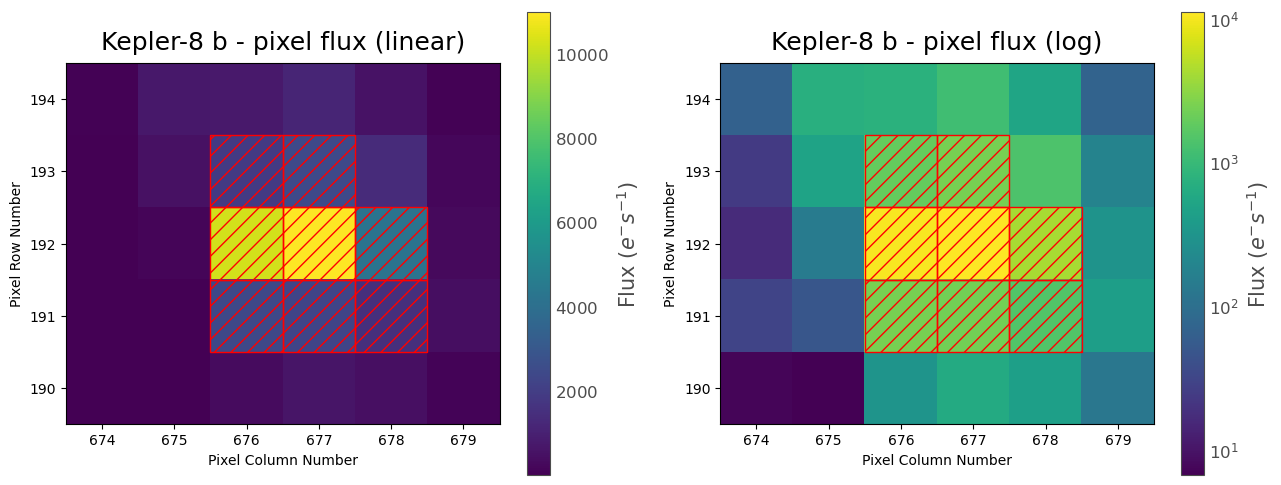

In [20]:
# Load and Visualize Target Pixel File
AUTHOR_PRIORITY = ["Kepler", "K2", "SPOC", "TESS-SPOC", "QLP"]
PREFER_SHORT_CADENCE = False

authors_present = list(dict.fromkeys(avail["author"].tolist()))
chosen_author = next((a for a in AUTHOR_PRIORITY if a in authors_present), authors_present[0])

subset = avail[avail["author"] == chosen_author].sort_values(
    "exptime_s", ascending=PREFER_SHORT_CADENCE
)
row = subset.iloc[0]
idx = int(subset.index[0])

print(f"✅ Selected: author={chosen_author}, exptime={row['exptime_s']:.0f}s, mission={row['mission']}")
print(f"✅ Downloading target pixel file (30-60 s for large Kepler quarters)...")
tpf = search[idx].download(quality_bitmask="default")

print(f"   Shape (cadences, rows, cols): {tpf.shape}")
print(f"   Cadences: {len(tpf.time)}   |   Baseline: {(tpf.time[-1] - tpf.time[0]).value:.1f} days")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
tpf.plot(ax=axes[0], aperture_mask=tpf.pipeline_mask,
         title=f"{SELECTED_PLANET} - pixel flux (linear)")
tpf.plot(ax=axes[1], aperture_mask=tpf.pipeline_mask, scale="log",
         title=f"{SELECTED_PLANET} - pixel flux (log)")
fig.tight_layout()
plt.show()


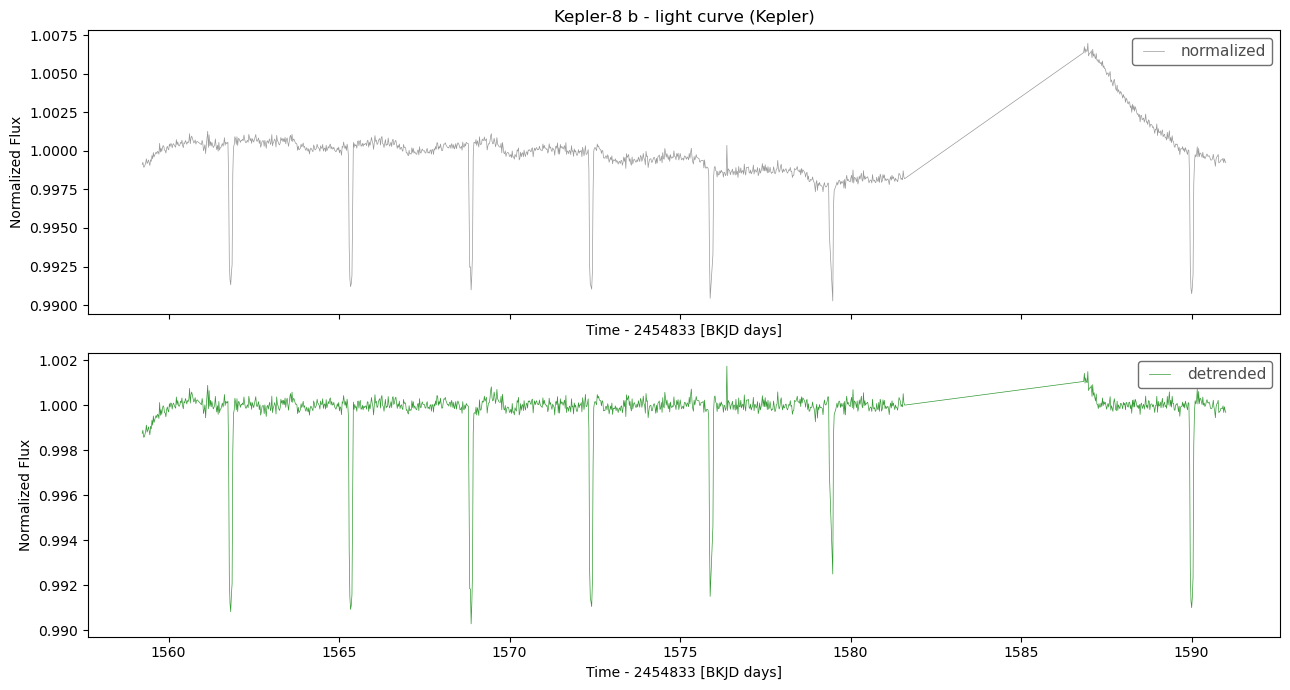

In [21]:
# 4. Extract Lightcurve and detrend
lc_raw = tpf.to_lightcurve(aperture_mask=tpf.pipeline_mask)
lc = lc_raw.remove_nans().remove_outliers(sigma=5).normalize()
lc_flat = lc.flatten(window_length=101)   # must be >> transit duration, << orbital period

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
lc.plot(ax=axes[0], c="grey", alpha=0.8, label="normalized")
axes[0].set_title(f"{SELECTED_PLANET} - light curve ({chosen_author})")
lc_flat.plot(ax=axes[1], c="green", alpha=0.8, label="detrended")
fig.tight_layout()
plt.show()

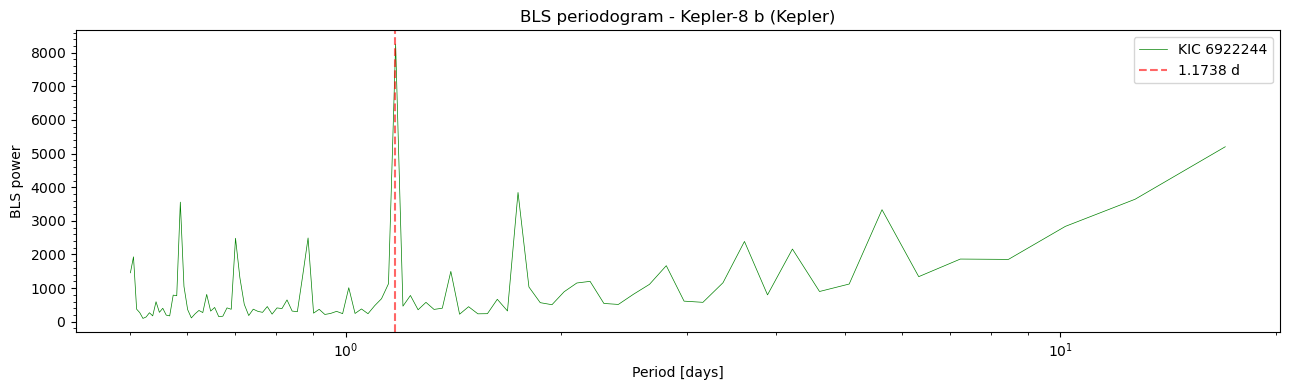

✅ Computing BLS periodogram (coarse pass, ~30-60 s)
  Coarse peak:     1.1749 days
✅ Refining around the peak:
  Orbital period:  1.17379 days  =  28.17 hours
  Transit epoch:   1559.4746
  Duration:        2.69 hours
  Depth:           2275 ppm  ->  Rp/Rs = 0.0477
  NASA catalog:    3.52250 days
  Deviation:       66.677 %


In [23]:
# Compute BLS-Periodogramm
# NOTE: minimum_period / maximum_period / period / duration must be PLAIN FLOATS in days.
# lightkurve computes the frequency grid spacing from the unitless lc.time.value, so passing
# astropy Quantities here raises "only dimensionless scalar quantities can be converted".

# Coarse pass peak calculation
DURATIONS = np.linspace(0.04, 0.30, 12)   # trial transit durations [days]

pg_coarse = lc_flat.to_periodogram(
    method="bls",
    minimum_period=0.5,
    maximum_period=20.0,
    duration=DURATIONS,
    frequency_factor=500,
)
p_coarse = pg_coarse.period_at_max_power          # <- comes back WITH units

# Refine on a narrow grid around the coarse peak (plain float array, again no units)
period_grid = np.linspace(0.98 * p_coarse.value, 1.02 * p_coarse.value, 4000)
pg = lc_flat.to_periodogram(method="bls", period=period_grid, duration=DURATIONS)

period   = pg.period_at_max_power
t0       = pg.transit_time_at_max_power
duration = pg.duration_at_max_power
depth    = float(pg.depth_at_max_power)

fig, ax = plt.subplots(figsize=(13, 4))
pg_coarse.plot(ax=ax, color="green")
ax.axvline(period.value, color="red", ls="--", alpha=0.6, label=f"{period.value:.4f} d")
ax.set_xscale("log")
ax.set_title(f"BLS periodogram - {SELECTED_PLANET} ({chosen_author})")
ax.set_xlabel("Period [days]")
ax.set_ylabel("BLS power")
ax.legend()
fig.tight_layout()
plt.show()

# Print results
print(f"✅ Computing BLS periodogram (coarse pass, ~30-60 s)")
print(f"  Coarse peak:     {p_coarse.value:.4f} days")
print("✅ Refining around the peak:")
print(f"  Orbital period:  {period.value:.5f} days  =  {period.value * 24:.2f} hours")
print(f"  Transit epoch:   {t0.value:.4f}")
print(f"  Duration:        {duration.value * 24:.2f} hours")
print(f"  Depth:           {depth * 1e6:.0f} ppm  ->  Rp/Rs = {np.sqrt(depth):.4f}")
print(f"  NASA catalog:    {info['pl_orbper']:.5f} days")
print(f"  Deviation:       {abs(period.value - info['pl_orbper']) / info['pl_orbper'] * 100:.3f} %")

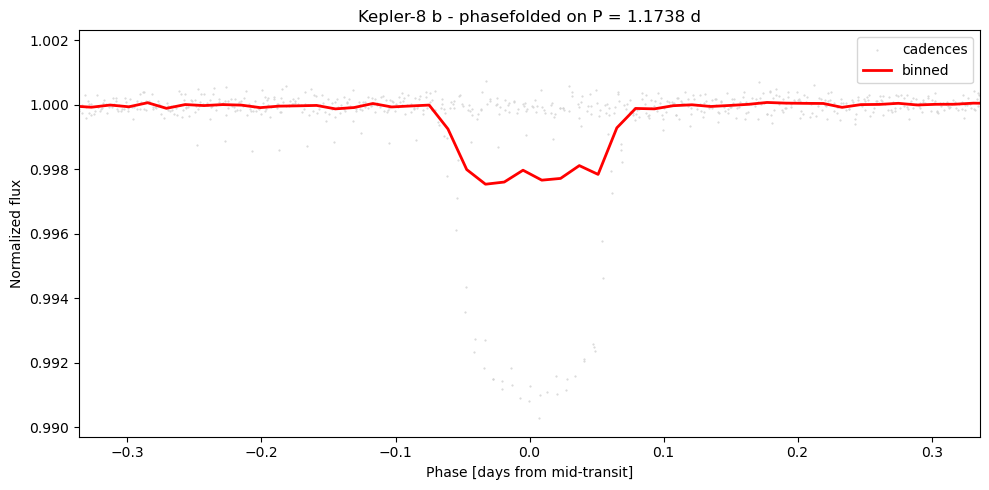

In [24]:
# Phase-folded Lightcurve
folded = lc_flat.fold(period=period, epoch_time=t0)
fig, ax = plt.subplots(figsize=(10, 5))
folded.scatter(ax=ax, c="lightgrey", s=1, label="cadences")
folded.bin(time_bin_size=duration / 8).plot(ax=ax, c="red", lw=2, label="binned")
ax.set_xlim(-3 * duration.value, 3 * duration.value)
ax.set_xlabel("Phase [days from mid-transit]")
ax.set_ylabel("Normalized flux")
ax.set_title(f"{SELECTED_PLANET} - phasefolded on P = {period.value:.4f} d")
ax.legend()
fig.tight_layout()
plt.show()

<font color="blue">*7. Transit model fit: planet radius, orbit and stellar density*</font>

The BLS box gives period, epoch and an approximate depth. A physical transit model also describes the *shape* of the transit:

* ingress and egress depend on the radius ratio $R_p/R_\star$, the impact parameter $b$ and the scaled orbital distance $a/R_\star$;
* the curved bottom comes from limb darkening (quadratic law, in the $q_1, q_2$ parametrization of Kipping 2013);
* from $a/R_\star$ and the period, Kepler's third law gives the mean stellar density $\rho_\star = 3\pi (a/R_\star)^3 / (G P^2)$, without knowing the star's mass or radius.

Steps in the cell:

1. Pipeline light curves (PDCSAP flux) of several quarters or sectors, at short cadence when available (1 min for Kepler, 2 min for TESS), so that ingress and egress are resolved.
2. Ephemeris from a BLS search on a narrow grid around the catalogue period.
3. Detrending with the transits masked, phase folding, 2-minute bins.
4. Least-squares fit of the model, started from four impact parameters. $b$, $a/R_\star$ and limb darkening are strongly correlated; a single start at $b = 0.4$ got stuck in a local minimum with systematic residuals at ingress and egress.

Result for Kepler-8 b (6 months at 1-min cadence, 51 orbits, reduced $\chi^2 = 1.09$):

| | Fit | Catalogue |
|---|---|---|
| $R_p/R_\star$ | 0.0971 | 0.0958 |
| $a/R_\star$ | 6.58 | 6.85 |
| $b$ | 0.753 | 0.719 |
| $T_{14}$ | 3.29 h | 3.19 h |
| $R_p$ | 15.7 $R_\oplus$ | 15.9 $R_\oplus$ |
| $\rho_\star$ | 0.435 g/cm³ | 0.654 (`st_dens`) / 0.521 (from $M_\star$, $R_\star$) g/cm³ |

* The quoted errors are statistical only. Real uncertainties are larger because limb darkening is free and correlated with $b$; the standard next step is an MCMC with limb-darkening priors from stellar atmosphere models.
* The BLS box underestimates $R_p/R_\star$ (0.091) because it ignores limb darkening and the finite ingress.
* The composite catalogue table mixes sources: its `st_dens` does not match its own stellar mass and radius.
* **Note on the BLS cell above:** MAST returns the search results in varying order, so the target pixel file (and the quarter) can change between runs. With Quarter 17 and `frequency_factor=500` the coarse BLS grid lands on 1/3 of the true period of Kepler-8 b. This section therefore refines the ephemeris around the catalogue period and prints a warning when the BLS result disagrees.

✅ Downloading 6 of 31 light curves (Kepler, 60 s cadence)...
   248523 cadences, baseline 180 days
⚠️ The BLS period above (1.1738 d) is not the catalogue period (3.5225 d) (alias or wrong peak); this section uses the refined ephemeris.


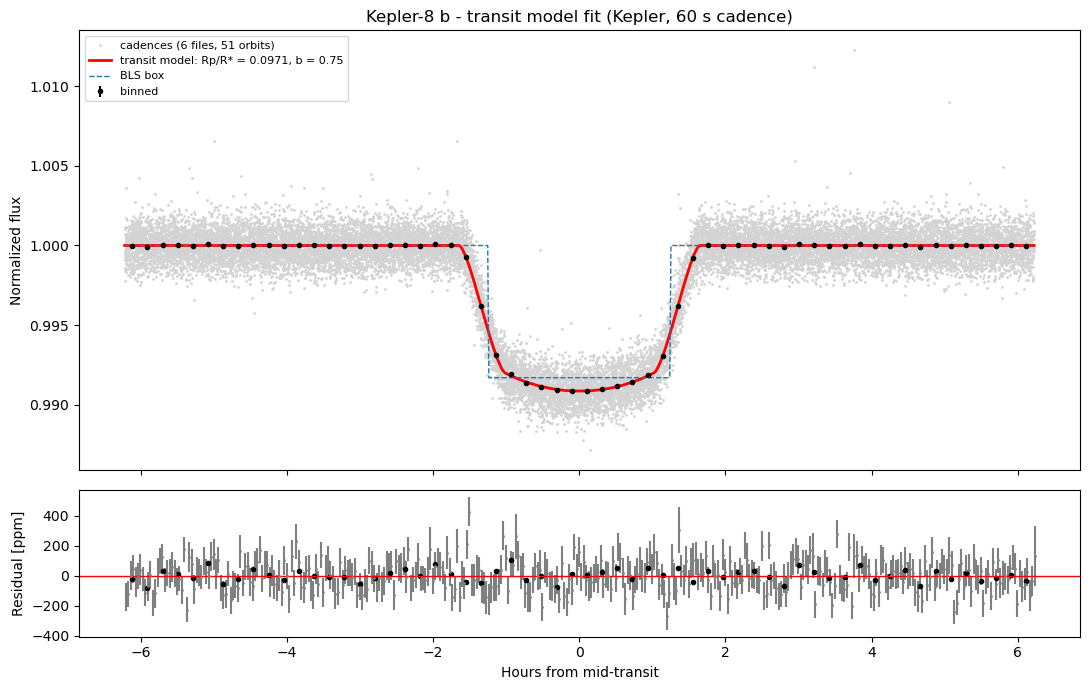

✅ Ephemeris:  P = 3.52241 d (catalogue 3.52250 d),  T0 = 170.4366
✅ Transit model fit  (reduced chi² = 1.09; errors: statistical only)     fit                   catalogue
  Radius ratio Rp/R*:      0.0971 ± 0.0003      0.0958   (BLS box: 0.0911)
  Scaled distance a/R*:    6.58 ± 0.01          6.85
  Impact parameter b:      0.753 ± 0.0003       0.719
  Inclination:             83.43 deg             83.98 deg
  Transit duration T14:    3.29 h                3.19 h
  Limb darkening u1, u2:   0.73, -0.32   (free; correlated with b and a/R*)
  Planet radius:           15.74 R_earth         15.87 R_earth   (with catalogue R* = 1.49 R_sun)
  Stellar density:         0.435 ± 0.003 g/cm³    0.654 g/cm³ (st_dens), 0.521 g/cm³ (from M*, R*)   (Sun: 1.41 g/cm³)


In [25]:
# 7. Transit model fit: planet radius, orbit geometry and stellar density
# Goal: go beyond the BLS box and fit a physical transit model (quadratic limb darkening) to many stacked transits,
#       then compare radius ratio, orbit and stellar density with the catalogue
from scipy.optimize import curve_fit
from astropy.timeseries import BoxLeastSquares

G_CGS = 6.674e-8   # gravitational constant [cm^3 g^-1 s^-2]
N_FILES = 6        # light-curve files to stack (Kepler: one quarter at 30 min, one month at 1 min; TESS: one sector)
SHORT_CADENCE = True   # 1-2 min cadence resolves ingress/egress, which pins down impact parameter and limb darkening

def transit_flux(z, p, u1, u2, n_r=400):
    """Relative flux of a star with quadratic limb darkening, occulted by a planet of radius p (in stellar radii)
    at projected separation z. Numerical integration over stellar annuli (accurate to ~1e-6)."""
    r = (np.arange(n_r) + 0.5) / n_r                        # annulus radii on the stellar disk
    mu = np.sqrt(1 - r ** 2)
    I = 1 - u1 * (1 - mu) - u2 * (1 - mu) ** 2              # limb-darkened intensity
    z = np.atleast_1d(z)[:, None]
    # half-angle of the arc of annulus r that lies inside the planet disk
    cos_th = np.clip((r ** 2 + z ** 2 - p ** 2) / (2 * r * np.maximum(z, 1e-12)), -1, 1)
    theta = np.where(r + z <= p, np.pi, np.where(np.abs(r - z) >= p, 0.0, np.arccos(cos_th)))
    return 1 - (I * theta * r).sum(axis=1) / (np.pi * (I * r).sum())

def transit_model(t, dt0, p, a_rs, b, q1, q2, period_d, exptime_d, n_sub=7):
    """Circular orbit; t in days from mid-transit. Limb darkening via Kipping (2013): q1, q2 in [0, 1].
    Each cadence is averaged over its exposure time (Kepler long cadence = 30 min smears ingress and egress)."""
    u1, u2 = 2 * np.sqrt(q1) * q2, np.sqrt(q1) * (1 - 2 * q2)
    inc = np.arccos(np.clip(b / a_rs, 0, 1))
    offsets = (np.arange(n_sub) - (n_sub - 1) / 2) / n_sub * exptime_d
    phase = 2 * np.pi * (np.asarray(t)[:, None] + offsets - dt0).ravel() / period_d
    z = a_rs * np.sqrt(np.sin(phase) ** 2 + (np.cos(inc) * np.cos(phase)) ** 2)
    z = np.where(np.cos(phase) > 0, z, 10.0)                # planet behind the star: no transit
    return transit_flux(z, p, u1, u2).reshape(len(t), n_sub).mean(axis=1)

def running_median(t, f, window_d, use):
    """Trend = running median over the points in `use` (window in days), interpolated to all times."""
    s = pd.Series(f[use], index=pd.to_datetime(t[use], unit="D"))
    trend = s.rolling(pd.Timedelta(days=window_d), center=True, min_periods=5).median().to_numpy()
    return np.interp(t, t[use], trend)

def fold_phase(t, P, t0):
    return (t - t0 + 0.5 * P) % P - 0.5 * P                 # days from the nearest mid-transit

# Data: several quarters / sectors of pipeline light curves (PDCSAP flux: systematics and crowding corrected)
lc_search = lk.search_lightcurve(SELECTED_PLANET, author=chosen_author)
exptimes = np.asarray(lc_search.table["exptime"], dtype=float)
FIT_EXPTIME = exptimes.min() if SHORT_CADENCE and exptimes.min() <= 120 else row["exptime_s"]
lc_search = lc_search[exptimes == FIT_EXPTIME]
lc_search = lc_search[np.argsort(np.asarray(lc_search.table["mission"]), kind="stable")]   # fixed order: Q00, Q01, ...
n_files = min(N_FILES, len(lc_search))
print(f"✅ Downloading {n_files} of {len(lc_search)} light curves ({chosen_author}, {FIT_EXPTIME:.0f} s cadence)...")
stitched = lc_search[:n_files].download_all(quality_bitmask="default").stitch()   # each file normalized to 1
unmask = lambda q: np.asarray(getattr(q, "unmasked", q).value, dtype=float)    # plain arrays (no masked columns)
t_all, f_all, e_all = unmask(stitched.time), unmask(stitched.flux), unmask(stitched.flux_err)
good = np.isfinite(t_all) & np.isfinite(f_all) & np.isfinite(e_all)
t_all, f_all, e_all = t_all[good], f_all[good], e_all[good]
order = np.argsort(t_all)
t_all, f_all, e_all = t_all[order], f_all[order], e_all[order]
print(f"   {len(t_all)} cadences, baseline {np.ptp(t_all):.0f} days")

# Ephemeris: BLS on a narrow grid around the catalogue period (robust against aliases)
cat = NasaExoplanetArchive.query_criteria(
    table="pscomppars", where=f"pl_name='{SELECTED_PLANET}'",
    select="pl_name,st_mass,st_rad,st_dens,pl_ratror,pl_ratdor,pl_orbincl,pl_imppar,pl_trandur,pl_rade").to_pandas().iloc[0]
P_cat = info["pl_orbper"]
T14_guess = cat["pl_trandur"] / 24 if np.isfinite(cat["pl_trandur"]) else 0.1
f_rough = f_all / running_median(t_all, f_all, 1.0, np.ones(len(t_all), bool))
bls = BoxLeastSquares(t_all, f_rough, e_all).power(np.linspace(0.998 * P_cat, 1.002 * P_cat, 3000),
                                                   T14_guess * np.array([0.6, 0.8, 1.0, 1.2]), objective="snr")
k = np.argmax(bls.power)
P_d, t0_d, T14, depth_bls = bls.period[k], bls.transit_time[k], bls.duration[k], bls.depth[k]
if abs(period.value - P_cat) / P_cat > 0.01:
    print(f"⚠️ The BLS period above ({period.value:.4f} d) is not the catalogue period ({P_cat:.4f} d) "
          f"(alias or wrong peak); this section uses the refined ephemeris.")

# Detrend with the transits masked, then fold
out_of_transit = np.abs(fold_phase(t_all, P_d, t0_d)) > 0.75 * T14
f_det = f_all / running_median(t_all, f_all, max(3 * T14, 0.75), out_of_transit)
ph = fold_phase(t_all, P_d, t0_d)
win = np.abs(ph) < 2.5 * T14
t_fit, f_fit, e_fit = ph[win], f_det[win], e_all[win]

# Phase-bin to 2-minute bins: the fit then runs on a few hundred points instead of tens of thousands
# (the exposure time of each cadence is still modelled; 2 min is much shorter than ingress/egress)
BIN_D = 2 / 1440
edges_fit = np.arange(-2.5 * T14, 2.5 * T14 + BIN_D, BIN_D)
ib = np.digitize(t_fit, edges_fit) - 1
nbins = len(edges_fit) - 1
n_in = np.bincount(ib, minlength=nbins)[:nbins]
s1 = np.bincount(ib, weights=f_fit, minlength=nbins)[:nbins]
s2 = np.bincount(ib, weights=f_fit ** 2, minlength=nbins)[:nbins]
ok = n_in >= 3
tb = (0.5 * (edges_fit[1:] + edges_fit[:-1]))[ok]
fb = s1[ok] / n_in[ok]
eb = np.sqrt(np.maximum(s2[ok] / n_in[ok] - fb ** 2, 1e-12) / (n_in[ok] - 1))    # standard error of the mean
EXPTIME_D = FIT_EXPTIME / 86400
N_SUB = 1 if FIT_EXPTIME <= 120 else 7                    # supersampling only needed for long cadence

model = lambda t, dt0, p, a_rs, b, q1, q2: transit_model(t, dt0, p, a_rs, b, q1, q2, P_d, EXPTIME_D, N_SUB)
bounds = ([-0.02, 0.01, 1.5, 0.0, 0.0, 0.0], [0.02, 0.5, 50.0, 1.2, 1.0, 1.0])
# b, a/R* and limb darkening are correlated: start from several impact parameters (with a/R* consistent with the
# transit duration T14 ≈ P/π · sqrt((1+p)² - b²) / (a/R*)) and keep the best fit, to avoid a local minimum
p_start = np.sqrt(max(depth_bls, 1e-5))
T14_obs = T14_guess if np.isfinite(T14_guess) else T14
best = None
for b_start in [0.1, 0.4, 0.6, 0.8]:
    a_start = np.clip(P_d / (np.pi * T14_obs) * np.sqrt((1 + p_start) ** 2 - b_start ** 2), 2, 40)
    try:
        popt_i, pcov_i = curve_fit(model, tb, fb, p0=[0.0, p_start, a_start, b_start, 0.36, 0.3], sigma=eb,
                                   absolute_sigma=True, bounds=bounds, maxfev=20000)
    except RuntimeError:
        continue
    chi2_i = np.sum(((fb - model(tb, *popt_i)) / eb) ** 2)
    if best is None or chi2_i < best[0]:
        best = (chi2_i, popt_i, pcov_i, b_start)
_, popt, pcov, b_start_best = best
perr = np.sqrt(np.diag(pcov))
dt0_fit, p_fit, a_fit, b_fit, q1_fit, q2_fit = popt
inc_fit = np.degrees(np.arccos(b_fit / a_fit))
chi2_red = np.sum(((fb - model(tb, *popt)) / eb) ** 2) / (len(tb) - len(popt))

# Stellar density from Kepler's third law: rho_star = 3 pi (a/R*)^3 / (G P^2)   (valid for M_p << M_star)
rho_fit = 3 * np.pi * a_fit ** 3 / (G_CGS * (P_d * 86400) ** 2)
rho_err = rho_fit * 3 * perr[2] / a_fit
rho_mr = cat["st_mass"] * 1.989e33 / (4 / 3 * np.pi * (cat["st_rad"] * 6.957e10) ** 3)   # from catalogue M*, R*
T14_fit = P_d / np.pi * np.arcsin(np.sqrt((1 + p_fit) ** 2 - b_fit ** 2) / (a_fit * np.sin(np.radians(inc_fit))))

tt = np.linspace(-2.5 * T14, 2.5 * T14, 800)
edges = np.linspace(-2.5 * T14, 2.5 * T14, 61)
idx = np.digitize(t_fit, edges) - 1
t_bin = 0.5 * (edges[1:] + edges[:-1])
f_bin = np.array([np.mean(f_fit[idx == i]) if np.any(idx == i) else np.nan for i in range(60)])
e_bin = np.array([np.std(f_fit[idx == i]) / np.sqrt(max((idx == i).sum(), 1)) for i in range(60)])

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
sub = np.random.default_rng(0).choice(len(t_fit), min(len(t_fit), 20000), replace=False)   # plot at most 20k points
axes[0].scatter(t_fit[sub] * 24, f_fit[sub], s=1, c="lightgrey", label=f"cadences ({n_files} files, {int(np.ptp(t_all) / P_d)} orbits)")
axes[0].errorbar(t_bin * 24, f_bin, e_bin, fmt="o", c="black", ms=3, label="binned")
axes[0].plot(tt * 24, model(tt, *popt), c="red", lw=2, label=f"transit model: Rp/R* = {p_fit:.4f}, b = {b_fit:.2f}")
axes[0].plot(tt * 24, 1 - depth_bls * (np.abs(tt) < T14 / 2), c="tab:blue", lw=1, ls="--", label="BLS box")
axes[0].set_ylabel("Normalized flux")
axes[0].set_title(f"{SELECTED_PLANET} - transit model fit ({chosen_author}, {FIT_EXPTIME:.0f} s cadence)")
axes[0].legend(fontsize=8)
axes[1].errorbar(tb * 24, (fb - model(tb, *popt)) * 1e6, eb * 1e6, fmt=".", c="grey", ms=2, label="2-min bins")
axes[1].plot(t_bin * 24, (f_bin - model(t_bin, *popt)) * 1e6, "o", c="black", ms=3)
axes[1].axhline(0, color="red", lw=1)
axes[1].set_xlabel("Hours from mid-transit")
axes[1].set_ylabel("Residual [ppm]")
fig.tight_layout()
plt.show()

# Print results
u1_fit, u2_fit = 2 * np.sqrt(q1_fit) * q2_fit, np.sqrt(q1_fit) * (1 - 2 * q2_fit)
print(f"✅ Ephemeris:  P = {P_d:.5f} d (catalogue {P_cat:.5f} d),  T0 = {t0_d + dt0_fit:.4f}")
print(f"✅ Transit model fit  (reduced chi² = {chi2_red:.2f}; errors: statistical only)     fit                   catalogue")
print(f"  Radius ratio Rp/R*:      {p_fit:.4f} ± {perr[1]:.4f}      {cat['pl_ratror']:.4f}   (BLS box: {np.sqrt(depth_bls):.4f})")
print(f"  Scaled distance a/R*:    {a_fit:.2f} ± {perr[2]:.2f}          {cat['pl_ratdor']:.2f}")
print(f"  Impact parameter b:      {b_fit:.3f} ± {perr[3]:.4f}       {cat['pl_imppar']:.3f}")
print(f"  Inclination:             {inc_fit:.2f} deg             {cat['pl_orbincl']:.2f} deg")
print(f"  Transit duration T14:    {T14_fit * 24:.2f} h                {cat['pl_trandur']:.2f} h")
print(f"  Limb darkening u1, u2:   {u1_fit:.2f}, {u2_fit:.2f}   (free; correlated with b and a/R*)")
print(f"  Planet radius:           {p_fit * cat['st_rad'] * 109.08:.2f} R_earth         {cat['pl_rade']:.2f} R_earth   (with catalogue R* = {cat['st_rad']:.2f} R_sun)")
print(f"  Stellar density:         {rho_fit:.3f} ± {rho_err:.3f} g/cm³    {cat['st_dens']:.3f} g/cm³ (st_dens), "
      f"{rho_mr:.3f} g/cm³ (from M*, R*)   (Sun: 1.41 g/cm³)")

<font color="blue">*8. Vetting and classical imaging: is the transit really on the target star?*</font>

Many transit-like signals are false positives, for example an eclipsing binary blended with the target in the same pixels. The Kepler and TESS pipelines test for this ("data validation"); the cell reproduces the main tests:

* **Difference imaging:** the mean pixel image out of transit minus the mean image in transit. The pixels that lose light show where the dip comes from, and their centroid should coincide with the target. Pixels are large (Kepler 3.98″, TESS 21″), so several stars often share a pixel: this is the classical resolution limit that better imaging, and eventually quantum-limited imaging, would push.
* **Gaia DR3 neighbours** on the pixel grid, and a rough contamination estimate from their G magnitudes (ignores the point-spread function), compared with the pipeline value $1 - $ `CROWDSAP` of the loaded quarter.
* **Odd/even depths:** an eclipsing binary at twice the period would show alternating depths.
* **Secondary eclipse** at phase 0.5: for a hot Jupiter it is tens of ppm in the Kepler band, for an eclipsing binary much deeper.

Result for Kepler-8 b:

* **Difference image:** centroid offset 0.27″ (0.07 pixel) from the out-of-transit centroid, peak S/N 6.3 from 25 in-transit cadences of a single quarter. The dip is on the target.
* **Gaia DR3:** 4 stars within 19″, 2 inside the aperture; own contamination estimate 0.7 %. The pipeline value depends on the quarter and stays at or below 0.3 % (0.0 % for Quarter 17, 0.05 % for Quarter 1).
* **Odd/even depth:** 8877 ± 23 ppm vs. 8886 ± 22 ppm (0.3 σ, 50 transits).
* **Secondary eclipse:** 11 ± 15 ppm, 3σ upper limit 56 ppm.
* All tests are consistent with a planet.

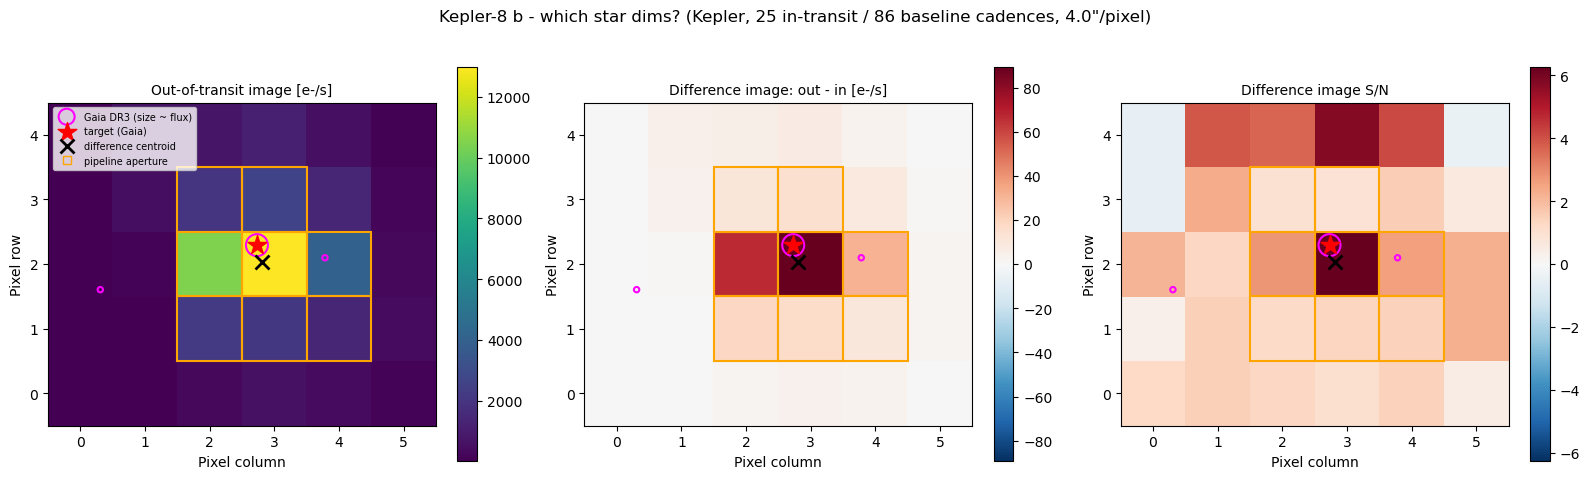

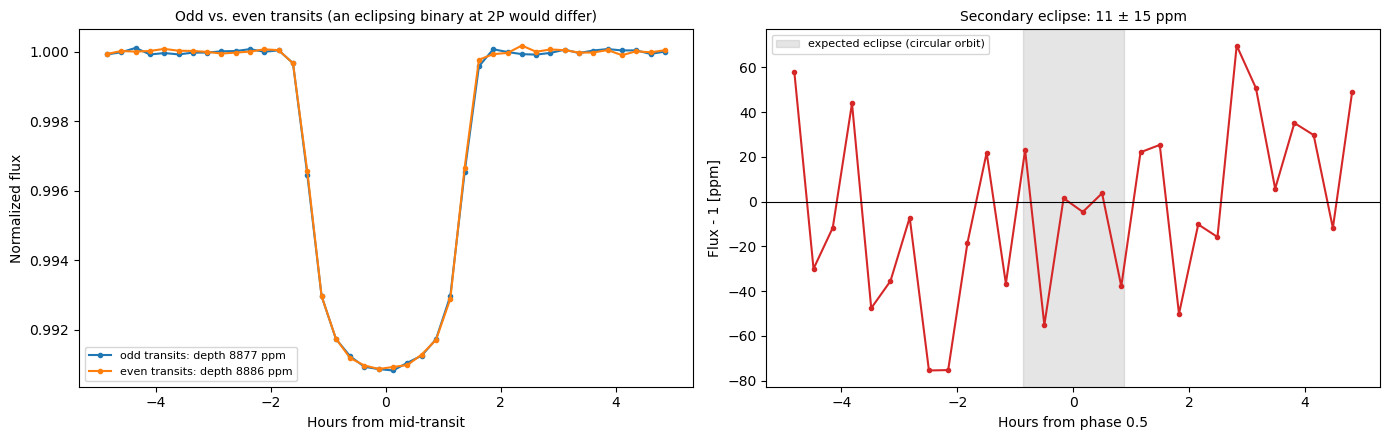

✅ Difference imaging (25 in-transit cadences)
  Centroid offset (difference vs. out-of-transit): 0.27" = 0.07 pixel
  Peak S/N of the difference image: 6.3   ->  dip located on the target
✅ Gaia DR3: 4 stars within 19 arcsec, 2 inside the aperture
  Flux contamination (own, from Gaia G magnitudes): 0.71 %
  Flux contamination (pipeline, 1 - CROWDSAP):      0.00 %
✅ Eclipsing-binary tests (stacked light curve, 50 transits)
  Odd / even depth:    8877 ± 23 ppm  /  8886 ± 22 ppm   ->  difference 0.3 sigma
  Secondary eclipse:   11 ± 15 ppm   (3-sigma upper limit 56 ppm)


In [26]:
# 8. Vetting and classical imaging: is the transit really on the target star?
# (a) difference image in-transit vs. out-of-transit on the pixel data, (b) Gaia neighbours and flux contamination,
# (c) odd/even transit depths and search for a secondary eclipse (eclipsing-binary tests)
from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord
from astropy.wcs.utils import proj_plane_pixel_scales

T0_fit = t0_d + dt0_fit

# (a) Difference image from the target pixel file loaded above (one quarter / sector)
cube = unmask(tpf.flux)                                        # (cadences, rows, cols) in e-/s
t_tpf = unmask(tpf.time)
ph_tpf = fold_phase(t_tpf, P_d, T0_fit)
finite = np.isfinite(t_tpf) & np.isfinite(cube).all(axis=(1, 2))
in_t = finite & (np.abs(ph_tpf) < 0.35 * T14)                   # transit core
out_t = finite & (np.abs(ph_tpf) > 0.75 * T14) & (np.abs(ph_tpf) < 2.0 * T14)   # local baseline on both sides
img_out, img_in = cube[out_t].mean(axis=0), cube[in_t].mean(axis=0)
diff = img_out - img_in                                         # > 0 where light disappears during transit
diff_err = np.sqrt(cube[out_t].var(axis=0) / out_t.sum() + cube[in_t].var(axis=0) / in_t.sum())
diff_snr = diff / diff_err

def centroid(img):
    w = np.clip(img, 0, None)
    yy, xx = np.indices(img.shape)
    return (w * xx).sum() / w.sum(), (w * yy).sum() / w.sum()

cx_out, cy_out = centroid(img_out)
cx_dif, cy_dif = centroid(diff)
pix_arcsec = proj_plane_pixel_scales(tpf.wcs).mean() * 3600
offset_arcsec = np.hypot(cx_dif - cx_out, cy_dif - cy_out) * pix_arcsec

# (b) Gaia DR3 neighbours (positions at epoch 2016; proper motions of a few mas/yr are negligible at this pixel scale)
radius = pix_arcsec * max(tpf.shape[1:]) * 0.8 * u.arcsec
gaia = Vizier(columns=["Source", "RA_ICRS", "DE_ICRS", "Gmag"], row_limit=-1).query_region(
    SkyCoord(tpf.ra, tpf.dec, unit="deg"), radius=radius, catalog="I/355/gaiadr3")[0].to_pandas()
gx, gy = tpf.wcs.world_to_pixel(SkyCoord(gaia["RA_ICRS"].values, gaia["DE_ICRS"].values, unit="deg"))
gaia["x"], gaia["y"] = gx, gy
gaia["sep_arcsec"] = SkyCoord(gaia["RA_ICRS"].values, gaia["DE_ICRS"].values, unit="deg").separation(
    SkyCoord(tpf.ra, tpf.dec, unit="deg")).arcsec
target = gaia.loc[gaia["sep_arcsec"].idxmin()]
aperture = tpf.pipeline_mask
col_i, row_i = np.round(gaia["x"]).astype(int), np.round(gaia["y"]).astype(int)
inside = (col_i >= 0) & (row_i >= 0) & (col_i < aperture.shape[1]) & (row_i < aperture.shape[0])
gaia["in_aperture"] = False
gaia.loc[inside, "in_aperture"] = aperture[row_i[inside], col_i[inside]]
flux_rel = 10 ** (-0.4 * (gaia["Gmag"] - target["Gmag"]))
contam = flux_rel[gaia["in_aperture"] & (gaia["Source"] != target["Source"])].sum() / flux_rel[gaia["in_aperture"]].sum()
crowdsap = tpf.hdu[1].header.get("CROWDSAP", np.nan)            # pipeline: fraction of aperture flux from the target

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
panels = [(img_out, "Out-of-transit image [e-/s]", "viridis"),
          (diff, "Difference image: out - in [e-/s]", "RdBu_r"),
          (diff_snr, "Difference image S/N", "RdBu_r")]
for ax, (img, title, cmap) in zip(axes, panels):
    lim = np.nanmax(np.abs(img)) if cmap == "RdBu_r" else None
    im = ax.imshow(img, origin="lower", cmap=cmap, vmin=-lim if lim else None, vmax=lim)
    fig.colorbar(im, ax=ax, fraction=0.046)
    for yy_, xx_ in zip(*np.nonzero(aperture)):                     # pipeline aperture: outline each pixel
        ax.add_patch(plt.Rectangle((xx_ - 0.5, yy_ - 0.5), 1, 1, fill=False, ec="orange", lw=1.5))
    sizes = 250 * 10 ** (-0.4 * (gaia["Gmag"] - target["Gmag"]))
    ax.scatter(gaia["x"], gaia["y"], s=np.clip(sizes, 15, 400), facecolors="none", edgecolors="magenta", lw=1.5, label="Gaia DR3 (size ~ flux)")
    ax.scatter([target["x"]], [target["y"]], marker="*", s=200, c="red", label="target (Gaia)")
    ax.plot(cx_dif, cy_dif, "x", c="black", ms=10, mew=2, label="difference centroid")
    ax.set_xlim(-0.5, img.shape[1] - 0.5)
    ax.set_ylim(-0.5, img.shape[0] - 0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Pixel column")
    ax.set_ylabel("Pixel row")
axes[0].plot([], [], "s", mfc="none", mec="orange", label="pipeline aperture")
axes[0].legend(fontsize=7, loc="upper left")
fig.suptitle(f"{SELECTED_PLANET} - which star dims? ({tpf.mission if hasattr(tpf, 'mission') else chosen_author}, "
             f"{in_t.sum()} in-transit / {out_t.sum()} baseline cadences, {pix_arcsec:.1f}\"/pixel)")
fig.tight_layout()
plt.show()

# (c) Eclipsing-binary tests on the stacked light curve from step 7
epoch = np.round((t_all - T0_fit) / P_d).astype(int)
core = np.abs(fold_phase(t_all, P_d, T0_fit)) < 0.35 * T14
def dip(sel_in, sel_ref):
    d = np.mean(f_det[sel_ref]) - np.mean(f_det[sel_in])
    return d, np.sqrt(np.var(f_det[sel_in]) / sel_in.sum() + np.var(f_det[sel_ref]) / sel_ref.sum())
ref = (np.abs(fold_phase(t_all, P_d, T0_fit)) > 0.75 * T14) & (np.abs(fold_phase(t_all, P_d, T0_fit)) < 2 * T14)
d_odd, e_odd = dip(core & (epoch % 2 == 1), ref & (epoch % 2 == 1))
d_even, e_even = dip(core & (epoch % 2 == 0), ref & (epoch % 2 == 0))
ph2 = fold_phase(t_all, P_d, T0_fit + P_d / 2)                   # phase 0.5 (circular orbit assumed)
d_sec, e_sec = dip(np.abs(ph2) < 0.35 * T14, (np.abs(ph2) > 0.75 * T14) & (np.abs(ph2) < 2 * T14))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for parity, c in [(1, "tab:blue"), (0, "tab:orange")]:
    sel = (epoch % 2 == parity) & (np.abs(fold_phase(t_all, P_d, T0_fit)) < 2 * T14)
    x = fold_phase(t_all, P_d, T0_fit)[sel] * 24
    e = np.linspace(-2 * T14 * 24, 2 * T14 * 24, 41)
    k = np.digitize(x, e) - 1
    axes[0].plot(0.5 * (e[1:] + e[:-1]), [np.mean(f_det[sel][k == i]) for i in range(40)], "o-", c=c, ms=3,
                 label=f"{'odd' if parity else 'even'} transits: depth {1e6 * (d_odd if parity else d_even):.0f} ppm")
axes[0].set_xlabel("Hours from mid-transit")
axes[0].set_ylabel("Normalized flux")
axes[0].set_title("Odd vs. even transits (an eclipsing binary at 2P would differ)", fontsize=10)
axes[0].legend(fontsize=8)
sel = np.abs(ph2) < 2 * T14
x = ph2[sel] * 24
e = np.linspace(-2 * T14 * 24, 2 * T14 * 24, 31)
k = np.digitize(x, e) - 1
axes[1].plot(0.5 * (e[1:] + e[:-1]), [1e6 * (np.mean(f_det[sel][k == i]) - 1) for i in range(30)], "o-", c="tab:red", ms=3)
axes[1].axvspan(-0.35 * T14 * 24, 0.35 * T14 * 24, color="grey", alpha=0.2, label="expected eclipse (circular orbit)")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xlabel("Hours from phase 0.5")
axes[1].set_ylabel("Flux - 1 [ppm]")
axes[1].set_title(f"Secondary eclipse: {1e6 * d_sec:.0f} ± {1e6 * e_sec:.0f} ppm", fontsize=10)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

# Print results
print(f"✅ Difference imaging ({in_t.sum()} in-transit cadences)")
print(f"  Centroid offset (difference vs. out-of-transit): {offset_arcsec:.2f}\" = {offset_arcsec / pix_arcsec:.2f} pixel")
print(f"  Peak S/N of the difference image: {np.nanmax(diff_snr):.1f}   ->  "
      f"{'dip located on the target' if offset_arcsec < pix_arcsec else 'CHECK: dip centroid is off target'}")
print(f"✅ Gaia DR3: {len(gaia)} stars within {radius:.0f}, {int(gaia['in_aperture'].sum())} inside the aperture")
print(f"  Flux contamination (own, from Gaia G magnitudes): {100 * contam:.2f} %")
print(f"  Flux contamination (pipeline, 1 - CROWDSAP):      {100 * (1 - crowdsap):.2f} %")
print(f"✅ Eclipsing-binary tests (stacked light curve, {len(np.unique(epoch[core]))} transits)")
print(f"  Odd / even depth:    {1e6 * d_odd:.0f} ± {1e6 * e_odd:.0f} ppm  /  {1e6 * d_even:.0f} ± {1e6 * e_even:.0f} ppm"
      f"   ->  difference {abs(d_odd - d_even) / np.hypot(e_odd, e_even):.1f} sigma")
print(f"  Secondary eclipse:   {1e6 * d_sec:.0f} ± {1e6 * e_sec:.0f} ppm   (3-sigma upper limit {1e6 * (max(d_sec, 0) + 3 * e_sec):.0f} ppm)")

<font color="blue">*9. Planet population: where does the selected planet sit among all known exoplanets?*</font>

Three standard diagrams from the full catalogue (`pscomppars`), with the selected planet marked:

* **Period–radius plane:** hot Jupiters at short periods and large radii, the sparsely populated "Neptunian desert" at short periods and intermediate radii, and the large population of small planets found by Kepler. Only measured radii are shown; the composite table fills radii of non-transiting planets from a mass–radius relation, which would appear as an artificial horizontal band.
* **Radius valley:** Fulton et al. (2017) found a deficit of planets between 1.5 and 2.0 $R_\oplus$ that separates rocky super-Earths from sub-Neptunes with gas envelopes. Here the valley is located as the minimum of a kernel density estimate in $\log R$ for planets with $P < 100$ d and radius precision better than 10 %.
* **Mass–radius diagram:** lines of constant density, an approximate Earth-like rocky relation ($R \approx M^{1/3.7}$ in Earth units, after Zeng et al. 2016) and the Solar System planets for reference.

Results:

* **Catalogue:** 6372 planets, of which 2462 have a measured (not minimum) mass.
* **Radius valley:** 1.82 $R_\oplus$ (1474 planets), inside the 1.5–2.0 $R_\oplus$ range of Fulton et al. The archive is not a homogeneous survey sample, and the valley position also depends on stellar mass and insolation, so this is a rough check.
* **Kepler-8 b:** mean density 0.26 g/cm³, well below Saturn (0.69 g/cm³): an inflated hot Jupiter.

✅ 6372 planets, 6322 with radius, 2462 with a measured (not minimum) mass


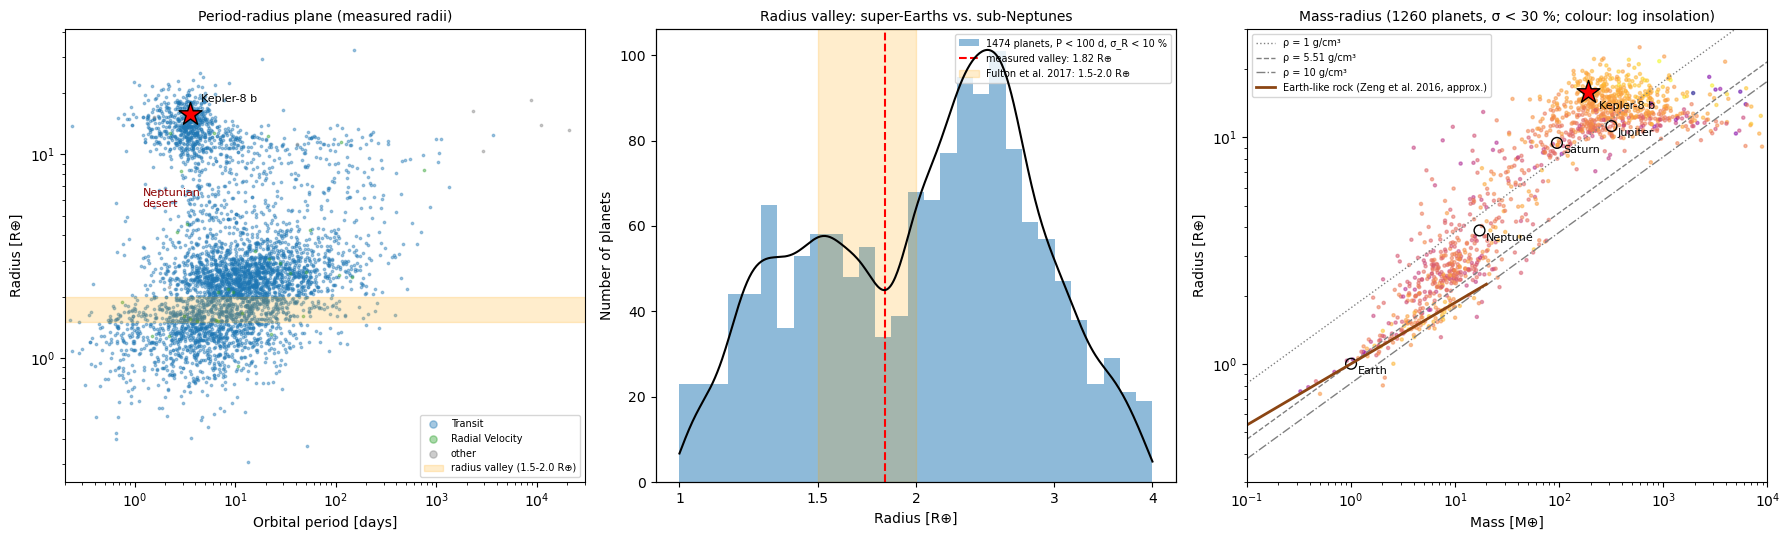

✅ Radius valley (own measurement): 1.82 R⊕   <- Fulton et al. (2017): deficit between 1.5 and 2.0 R⊕
✅ Kepler-8 b: P = 3.52 d, R = 15.87 R⊕, M = 187.5 M⊕, mean density 0.26 g/cm³ (Jupiter 1.33, Saturn 0.69, Earth 5.51)


In [27]:
# 9. Planet population: where does the selected planet sit among all known exoplanets?
# Period-radius plane, radius valley (Fulton et al. 2017), mass-radius diagram with composition curves
from scipy.stats import gaussian_kde

POP_COLUMNS = ("pl_name, discoverymethod, pl_orbper, pl_rade, pl_radeerr1, pl_radeerr2, "
               "pl_bmasse, pl_bmasseerr1, pl_bmasseerr2, pl_bmassprov, pl_insol, st_teff")
pop = NasaExoplanetArchive.query_criteria(table="pscomppars", select=POP_COLUMNS).to_pandas()
pop["rad_relerr"] = (pop["pl_radeerr1"] - pop["pl_radeerr2"]) / 2 / pop["pl_rade"]
pop["mass_relerr"] = (pop["pl_bmasseerr1"] - pop["pl_bmasseerr2"]) / 2 / pop["pl_bmasse"]
sel_pl = pop.loc[pop["pl_name"] == SELECTED_PLANET].iloc[0]
print(f"✅ {len(pop)} planets, {pop['pl_rade'].notna().sum()} with radius, "
      f"{(pop['pl_bmassprov'] == 'Mass').sum()} with a measured (not minimum) mass")

# Radius valley: planets with P < 100 d, precise radii (< 10 %), 1-4 R_earth; KDE in log radius, minimum between the peaks
small = pop[(pop["pl_orbper"] < 100) & (pop["rad_relerr"] < 0.10) & pop["pl_rade"].between(1.0, 4.0)]
logr = np.log10(small["pl_rade"])
kde = gaussian_kde(logr, bw_method=0.15)
grid = np.linspace(0, np.log10(4), 400)
dens = kde(grid)
search_range = (grid > np.log10(1.3)) & (grid < np.log10(2.6))
r_valley = 10 ** grid[search_range][np.argmin(dens[search_range])]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
# (a) Period-radius (only measured radii: the composite table fills radii of non-transiting planets from a mass-radius relation)
has_r = pop["pl_rade"].notna() & pop["pl_orbper"].notna() & pop["pl_radeerr1"].notna()
for method, c in [("Transit", "tab:blue"), ("Radial Velocity", "tab:green")]:
    m = has_r & (pop["discoverymethod"] == method)
    axes[0].scatter(pop.loc[m, "pl_orbper"], pop.loc[m, "pl_rade"], s=3, alpha=0.4, c=c, label=method)
m = has_r & ~pop["discoverymethod"].isin(["Transit", "Radial Velocity"])
axes[0].scatter(pop.loc[m, "pl_orbper"], pop.loc[m, "pl_rade"], s=3, alpha=0.4, c="grey", label="other")
axes[0].axhspan(1.5, 2.0, color="orange", alpha=0.2, label="radius valley (1.5-2.0 R⊕)")
axes[0].text(1.2, 5.5, "Neptunian\ndesert", fontsize=8, color="darkred")
axes[0].legend(fontsize=7, markerscale=3, loc="lower right")
axes[0].scatter([sel_pl["pl_orbper"]], [sel_pl["pl_rade"]], marker="*", s=300, c="red", edgecolor="black", zorder=5)
axes[0].annotate(SELECTED_PLANET, (sel_pl["pl_orbper"], sel_pl["pl_rade"]), xytext=(8, 8), textcoords="offset points", fontsize=8)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim(0.2, 3e4)
axes[0].set_xlabel("Orbital period [days]")
axes[0].set_ylabel("Radius [R⊕]")
axes[0].set_title("Period-radius plane (measured radii)", fontsize=10)

# (b) Radius valley
axes[1].hist(small["pl_rade"], bins=np.logspace(0, np.log10(4), 30), color="tab:blue", alpha=0.5, density=False,
             label=f"{len(small)} planets, P < 100 d, σ_R < 10 %")
ax_k = axes[1].twinx()
ax_k.plot(10 ** grid, dens, c="black", lw=1.5, label="KDE in log R")
ax_k.set_yticks([])
axes[1].axvline(r_valley, color="red", ls="--", label=f"measured valley: {r_valley:.2f} R⊕")
axes[1].axvspan(1.5, 2.0, color="orange", alpha=0.2, label="Fulton et al. 2017: 1.5-2.0 R⊕")
axes[1].set_xscale("log")
axes[1].set_xticks([1, 1.5, 2, 3, 4], ["1", "1.5", "2", "3", "4"])
axes[1].set_xlabel("Radius [R⊕]")
axes[1].set_ylabel("Number of planets")
axes[1].set_title("Radius valley: super-Earths vs. sub-Neptunes", fontsize=10)
axes[1].legend(fontsize=7, loc="upper right")

# (c) Mass-radius with composition curves
mr = pop[(pop["pl_bmassprov"] == "Mass") & (pop["mass_relerr"] < 0.3) & (pop["rad_relerr"] < 0.3)]
axes[2].scatter(mr["pl_bmasse"], mr["pl_rade"], s=5, alpha=0.5, c=np.log10(mr["pl_insol"].where(mr["pl_insol"] > 0)), cmap="plasma")
M = np.logspace(-1, 4, 200)
for rho, ls in [(1.0, ":"), (5.51, "--"), (10.0, "-.")]:
    R = (M * 5.972e27 / (4 / 3 * np.pi * rho)) ** (1 / 3) / 6.371e8          # constant density [g/cm³]
    axes[2].plot(M, R, c="grey", ls=ls, lw=1, label=f"ρ = {rho:g} g/cm³")
M_rock = np.logspace(-1, np.log10(20), 100)
axes[2].plot(M_rock, 1.0 * M_rock ** (1 / 3.7), c="saddlebrown", lw=2, label="Earth-like rock (Zeng et al. 2016, approx.)")
for name, m_e, r_e in [("Earth", 1, 1), ("Neptune", 17.15, 3.88), ("Saturn", 95.16, 9.45), ("Jupiter", 317.8, 11.21)]:
    axes[2].scatter([m_e], [r_e], marker="o", s=60, facecolors="none", edgecolors="black")
    axes[2].text(m_e * 1.15, r_e * 0.9, name, fontsize=8)
axes[2].scatter([sel_pl["pl_bmasse"]], [sel_pl["pl_rade"]], marker="*", s=300, c="red", edgecolor="black", zorder=5)
axes[2].annotate(SELECTED_PLANET, (sel_pl["pl_bmasse"], sel_pl["pl_rade"]), xytext=(8, -12), textcoords="offset points", fontsize=8)
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlim(0.1, 1e4)
axes[2].set_ylim(0.3, 30)
axes[2].set_xlabel("Mass [M⊕]")
axes[2].set_ylabel("Radius [R⊕]")
axes[2].set_title(f"Mass-radius ({len(mr)} planets, σ < 30 %; colour: log insolation)", fontsize=10)
axes[2].legend(fontsize=7, loc="upper left")
fig.tight_layout()
plt.show()

# Print results
rho_pl = sel_pl["pl_bmasse"] * 5.972e27 / (4 / 3 * np.pi * (sel_pl["pl_rade"] * 6.371e8) ** 3)
print(f"✅ Radius valley (own measurement): {r_valley:.2f} R⊕   <- Fulton et al. (2017): deficit between 1.5 and 2.0 R⊕")
print(f"✅ {SELECTED_PLANET}: P = {sel_pl['pl_orbper']:.2f} d, R = {sel_pl['pl_rade']:.2f} R⊕, M = {sel_pl['pl_bmasse']:.1f} M⊕, "
      f"mean density {rho_pl:.2f} g/cm³ (Jupiter 1.33, Saturn 0.69, Earth 5.51)")

<font color="blue">*10. JWST transmission spectrum: which molecules, and why is the planet cooler than expected?*</font>

During a transit, starlight passes through the planet's atmosphere. At wavelengths where a molecule absorbs, the atmosphere is opaque higher up, so the planet looks larger and the transit is deeper: transit depth $= (R_p(\lambda)/R_\star)^2$. One atmospheric scale height $H = kT/(\mu m_H g)$ changes the depth by about $2 R_p H / R_\star^2$.

Example: HATS-6 b, a warm gas giant around an M dwarf, observed with JWST NIRSpec PRISM (0.6–5.3 µm, two transits). Guzmán Caloca et al. (2026, AJ 172, 193) detect H₂O, CH₄, CO₂ and NH₃ and retrieve a temperature of about 514 K, about 200 K below the equilibrium temperature of 713 K. They explain this with a high Bond albedo (≈ 0.71) from reflective clouds or haze.

The cell:

1. Queries the `spectra` table of the NASA Exoplanet Archive and downloads the published spectra (visit 1, visit 2, co-added).
2. Marks the approximate centres of the strongest bands.
3. Converts the depth axis into scale heights.
4. Recomputes the equilibrium temperature $T_\mathrm{eq} = T_\star \sqrt{R_\star / 2a}$ (zero albedo, full heat redistribution) and the albedo needed for the retrieved temperature.

Results (own inference from the published spectrum):

* **Scale height:** $g = 8.0$ m/s² and $H = 321$ km at 713 K give 291 ppm per scale height. This is large because the host star is small ($R_\star = 0.57\,R_\odot$).
* **Band excess above the median depth:** CH₄ +511 ppm (1.8 $H$ at 713 K, 2.4 $H$ at 514 K) at 2.3 and 3.3 µm is the clearest feature; H₂O, NH₃ and CO₂ each give about +230 ppm.
* **Temperature:** $T_\mathrm{eq} = 713$ K, matching the catalogue. A temperature of 514 K requires a Bond albedo $A = 1 - (T/T_\mathrm{eq})^4 = 0.73$, consistent with the paper's ≈ 0.71.

Caveats:

* Marking bands is not a detection. Feature amplitudes depend jointly on abundances, clouds and temperature, and the paper's results come from a full atmospheric retrieval. The natural next step is a forward model or retrieval with petitRADTRANS or TauREx.
* The spectrum files are served from a session workspace of the archive's web interface. This is not a documented API and may change.
* Other planets work too, for example `SPEC_PLANET = "WASP-39 b"` for the CO₂ feature at 4.3 µm.

✅ 3 spectra of HATS-6 b in the NASA Exoplanet Archive


,spec_type,instrument,minwavelng,maxwavelng,num_datapoints,authors,note
0,Transmission,Near Infrared Spectrograph (NIRSpec) - PRISM,0.5492,5.6377,470,Guzmán Caloca et al. 2026,Visit 1; Eureka1 pipeline; Figure 2
1,Transmission,Near Infrared Spectrograph (NIRSpec) - PRISM,0.5547,5.6489,470,Guzmán Caloca et al. 2026,Visit 2; Eureka1 pipeline; Figure 2
2,Transmission,Near Infrared Spectrograph (NIRSpec) - PRISM,0.6200,5.3800,120,Guzmán Caloca et al. 2026,Co-added spectrum; Eureka1 pipeline; Figure 2


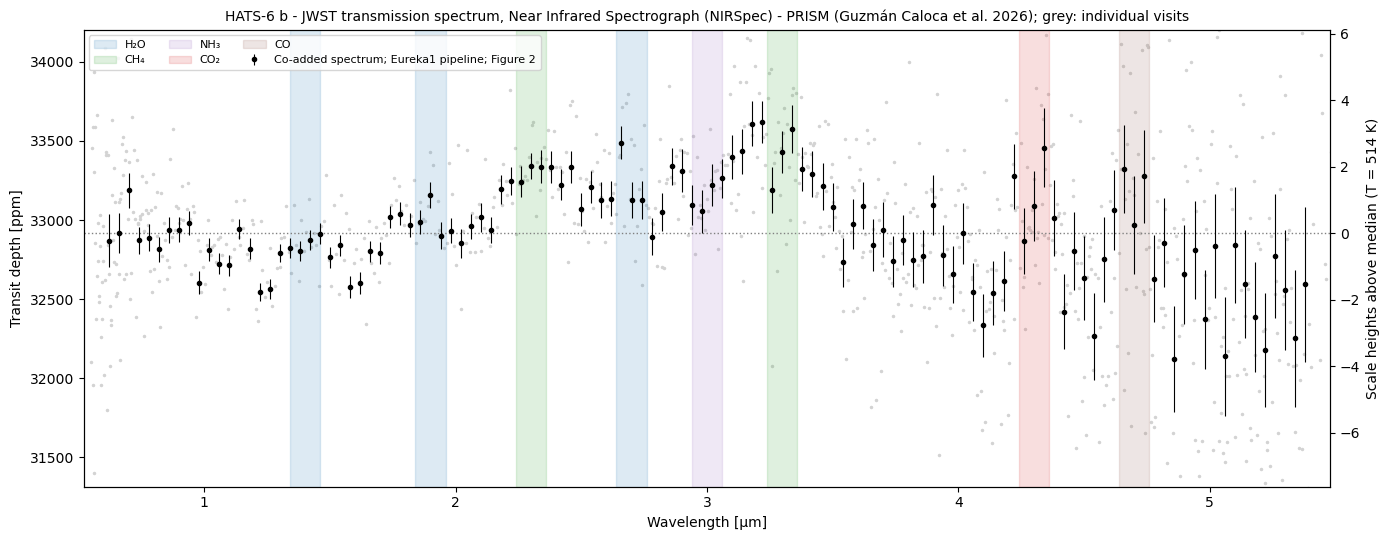

✅ HATS-6 b: g = 8.0 m/s², scale height H = 321 km at 713 K -> 291 ppm per scale height
  Band excess above the median depth (strongest band per molecule):
    H₂O    +237 ppm  =  +0.8 H (at 713 K)  /  +1.1 H (at 514 K)
    CH₄    +511 ppm  =  +1.8 H (at 713 K)  /  +2.4 H (at 514 K)
    NH₃    +241 ppm  =  +0.8 H (at 713 K)  /  +1.1 H (at 514 K)
    CO₂    +224 ppm  =  +0.8 H (at 713 K)  /  +1.1 H (at 514 K)
    CO     +135 ppm  =  +0.5 H (at 713 K)  /  +0.6 H (at 514 K)
✅ Equilibrium temperature (zero albedo, full heat redistribution): T_eq = T* √(R*/2a) = 713 K (catalogue 713 K)
  Retrieved temperature 514 K requires a Bond albedo A = 1 - (T/T_eq)^4 = 0.73  (paper: ≈ 0.71, reflective clouds or haze)


In [28]:
# 10. JWST transmission spectrum: which molecules, and why is the planet cooler than expected?
# Example: HATS-6 b, JWST NIRSpec PRISM (Guzmán Caloca et al. 2026, AJ 172, 193): H2O, CH4, CO2, NH3; T ≈ 514 K vs. T_eq = 713 K
import re
import requests
from astropy.io import ascii

SPEC_PLANET = "HATS-6 b"   # <- any planet with spectra in the archive, e.g. "WASP-39 b" (CO2 at 4.3 µm), "WASP-107 b"
T_RETRIEVED = 514          # K, atmospheric temperature retrieved in the paper (set None for other planets)
MU = 2.3                   # mean molecular weight of a hydrogen/helium atmosphere [atomic mass units]

def download_spectrum(spec_path):
    """Fetch one spectrum file from the NASA Exoplanet Archive. The archive serves these files from a session
    workspace (this mirrors what its web interface does; not a documented API)."""
    base = "https://exoplanetarchive.ipac.caltech.edu"
    page = requests.get(base + "/cgi-bin/atmospheres/nph-firefly?atmospheres", timeout=60).text
    workspace = re.search(r"/workspace/TMP_[A-Za-z0-9_]+", page).group(0)
    r = requests.get(f"{base}{workspace}/atmospheres/tab1/data/{spec_path}", timeout=60)
    r.raise_for_status()
    return ascii.read(r.text, format="ipac")

spec_meta = NasaExoplanetArchive.query_criteria(table="spectra", where=f"pl_name='{SPEC_PLANET}'").to_pandas()
spec_meta["authors"] = spec_meta["authors"].str.replace("&aacute;", "á")
print(f"✅ {len(spec_meta)} spectra of {SPEC_PLANET} in the NASA Exoplanet Archive")
display(spec_meta[["spec_type", "instrument", "minwavelng", "maxwavelng", "num_datapoints", "authors", "note"]])

# Primary spectrum: JWST transmission, co-added if available, otherwise the one with most points
jwst = spec_meta[spec_meta["facility"].str.contains("JWST") & (spec_meta["spec_type"] == "Transmission")].copy()
jwst["coadded"] = jwst["note"].str.contains("Co-added", case=False, na=False)
main = jwst.sort_values(["coadded", "num_datapoints"], ascending=False).iloc[0]
spectra = {r["note"]: download_spectrum(r["spec_path"]) for _, r in jwst[jwst["bibcode"] == main["bibcode"]].iterrows()}
spec = spectra[main["note"]]
wl, dep = np.array(spec["CENTRALWAVELNG"]), np.array(spec["PL_TRANDEP"]) * 1e4          # % -> ppm
err = np.array(spec["PL_TRANDEPERR1"]) * 1e4

# Planet and star from the catalogue: surface gravity, scale height, equilibrium temperature
pp = NasaExoplanetArchive.query_criteria(
    table="pscomppars", where=f"pl_name='{SPEC_PLANET}'",
    select="pl_name,pl_rade,pl_bmasse,pl_eqt,st_rad,st_teff,pl_ratdor").to_pandas().iloc[0]
R_p, M_p, R_s = pp["pl_rade"] * 6.371e8, pp["pl_bmasse"] * 5.972e27, pp["st_rad"] * 6.957e10   # cgs
g = G_CGS * M_p / R_p ** 2
scale_height = lambda T: 1.381e-16 * T / (MU * 1.6735e-24 * g)                                  # H = kT / (mu m_H g) [cm]
ppm_per_H = lambda T: 2 * R_p * scale_height(T) / R_s ** 2 * 1e6                                # depth change per H
T_eq0 = pp["st_teff"] * np.sqrt(1 / (2 * pp["pl_ratdor"]))                                     # zero albedo, full redistribution

# Approximate centres of the strongest bands in the NIRSpec PRISM range (identification needs a retrieval)
BANDS = {"H₂O": [1.4, 1.9, 2.7], "CH₄": [2.3, 3.3], "NH₃": [3.0], "CO₂": [4.3], "CO": [4.7]}
COLORS = {"H₂O": "tab:blue", "CH₄": "tab:green", "NH₃": "tab:purple", "CO₂": "tab:red", "CO": "tab:brown"}

fig, ax = plt.subplots(figsize=(14, 5.5))
for note, s in spectra.items():
    if note != main["note"]:
        ax.plot(np.array(s["CENTRALWAVELNG"]), np.array(s["PL_TRANDEP"]) * 1e4, ".", c="lightgrey", ms=3, zorder=1)
ax.errorbar(wl, dep, err, fmt="o", c="black", ms=3, lw=0.8, label=f"{main['note']}", zorder=3)
base = np.median(dep)
for mol, centres in BANDS.items():
    for i, c in enumerate(centres):
        if wl.min() < c < wl.max():
            ax.axvspan(c - 0.06, c + 0.06, color=COLORS[mol], alpha=0.15, label=mol if i == 0 else None)
ax.axhline(base, color="grey", ls=":", lw=1)
pad = 0.3 * np.ptp(dep)
ax.set_ylim((dep - err).min() - pad, (dep + err).max() + pad)          # individual visits have outliers at the edges
ax.set_xlim(wl.min() - 0.1, wl.max() + 0.1)
ax.set_xlabel("Wavelength [µm]")
ax.set_ylabel("Transit depth [ppm]")
ax.set_title(f"{SPEC_PLANET} - JWST transmission spectrum, {main['instrument']} ({main['authors']}); grey: individual visits",
             fontsize=10)
ax.legend(fontsize=8, ncol=3, loc="upper left")
ax_h = ax.twinx()                                                        # right axis: atmospheric scale heights
T_axis = T_RETRIEVED or pp["pl_eqt"]
ax_h.set_ylim((np.array(ax.get_ylim()) - base) / ppm_per_H(T_axis))
ax_h.set_ylabel(f"Scale heights above median (T = {T_axis:.0f} K)")
fig.tight_layout()
plt.show()

# Print results
feat = {mol: max(dep[np.abs(wl - c) < 0.1].mean() - base for c in cs if wl.min() < c < wl.max())
        for mol, cs in BANDS.items() if any(wl.min() < c < wl.max() for c in cs)}
print(f"✅ {SPEC_PLANET}: g = {g / 100:.1f} m/s², scale height H = {scale_height(pp['pl_eqt']) / 1e5:.0f} km at {pp['pl_eqt']:.0f} K "
      f"-> {ppm_per_H(pp['pl_eqt']):.0f} ppm per scale height")
print("  Band excess above the median depth (strongest band per molecule):")
for mol, a in feat.items():
    print(f"    {mol:4s} {a:+6.0f} ppm  =  {a / ppm_per_H(pp['pl_eqt']):+.1f} H (at {pp['pl_eqt']:.0f} K)"
          + (f"  /  {a / ppm_per_H(T_RETRIEVED):+.1f} H (at {T_RETRIEVED} K)" if T_RETRIEVED else ""))
print(f"✅ Equilibrium temperature (zero albedo, full heat redistribution): T_eq = T* √(R*/2a) = {T_eq0:.0f} K "
      f"(catalogue {pp['pl_eqt']:.0f} K)")
if T_RETRIEVED:
    A_B = 1 - (T_RETRIEVED / T_eq0) ** 4
    print(f"  Retrieved temperature {T_RETRIEVED} K requires a Bond albedo A = 1 - (T/T_eq)^4 = {A_B:.2f}  "
          f"(paper: ≈ 0.71, reflective clouds or haze)")

<font color="blue">*11. Direct imaging below the diffraction limit: classical imaging vs. SPADE*</font>

A camera records *where* each photon lands. When a faint planet sits inside the diffraction blur of its star, the two intensity profiles overlap, and the position data carry almost no information about the planet. **SPADE** (spatial-mode demultiplexing) instead sorts the light into Hermite–Gauss modes before counting photons. A point source exactly on the optical axis only populates mode 0; any off-axis light leaks into modes $q \ge 1$ with probability $e^{-Q} Q^q/q!$, $Q = x_0^2/4\sigma^2$ (Huang & Lupo, Eq. 19). Counting photons in mode 1 therefore detects the planet almost background-free.

The cell simulates the measurement statistics classically (no quantum hardware is needed to *compute* them). It uses a 1D Gaussian point-spread function whose intensity has standard deviation $\sigma$ (roughly 0.3–0.45 $\lambda/D$, depending on convention):

* **(a) Relevance:** maximum angular separation $a/d$ of all known planets in units of $\lambda/D$, for an 8-m and a 39-m telescope at 1.6 µm.
* **(b) Detection** (Huang & Lupo, arXiv:2106.00488): hypothesis test "star alone" vs. "star + planet with contrast $\varepsilon$ at separation $s$". The figure of merit is the error exponent per photon, the relative entropy $D(p_0\|p_1)$ (Stein's lemma).
  * Direct imaging: $D \approx \varepsilon^2 (e^{s^2/\sigma^2}-1)/2$ (their Eq. 9).
  * SPADE aligned on the optical centre of mass: $D \approx \varepsilon\,(1-e^{-s^2/4\sigma^2})$ (Eq. 23), which reaches the quantum limit to leading order in $\varepsilon$ (Eq. 17).
* **(c) Separation estimation** for two equally bright sources (Tsang, Nair, Lu, arXiv:1511.00552).
  * The Fisher information of direct imaging vanishes as $s \to 0$ ("Rayleigh's curse").
  * The quantum Fisher information stays at $1/(4\sigma^2)$ per photon (Eq. 3.11), and Hermite–Gauss mode counting attains it (Eq. 4.6).
  * A Monte-Carlo maximum-likelihood estimate from 10,000 photons checks the bounds.
* **Crosstalk:** an imperfect mode sorter sends a fraction of mode-0 photons into higher modes. This is modelled with a leak probability of $10^{-3}$ (own simple model; crosstalk limits are discussed in the literature, e.g. by Gessner, Fabre and Treps, 2020).

Results:

* **(a)** 5505 of 5917 planets with known orbit and distance lie below $\lambda/D$ for an 8-m telescope (5064 for 39 m). Most known planets are unresolvable, which is why they were found indirectly (transits, radial velocities).
* **(b)** At $s = 0.3\,\sigma$, SPADE improves the error exponent by 47× for $\varepsilon = 10^{-2}$ and by 4725× for $\varepsilon = 10^{-4}$, i.e. $\approx 1/(2\varepsilon)$ for $s \ll \sigma$, the $1/\varepsilon$ advantage of Huang & Lupo. For $\varepsilon = 10^{-4}$ this is $3\times10^{6}$ instead of $1.5\times10^{10}$ photons for a $10^{-3}$ miss probability.
* **(b)** With crosstalk $10^{-3}$, most of the advantage is lost once the planet's leak signal $\varepsilon Q$ drops below the crosstalk level.
* **(c)** At $s = 0.2\,\sigma$: SPADE RMSE 0.020 σ, equal to the quantum limit. Direct imaging RMSE 0.131 σ, with 26 % of the estimates stuck at $s = 0$ (a biased estimator near the boundary).

Caveats:

* The model is idealized: 1D, Gaussian point-spread function, weak-signal single-photon limit, perfect alignment, no speckle noise.
* In real high-contrast imaging, quasi-static speckles rather than photon shot noise usually dominate. Planets inside $\lambda/D$ also have extreme contrasts ($\sim10^{-4}$ for hot Jupiters in the infrared down to $\sim10^{-10}$ for Earth analogues).

In [ ]:
# 11. Direct imaging below the diffraction limit: classical imaging vs. SPADE (spatial-mode demultiplexing)
# Classical simulation of the measurement statistics; conventions of Tsang, Nair, Lu (arXiv:1511.00552) and
# Huang & Lupo (arXiv:2106.00488): 1D Gaussian point-spread function psi(x) = (2 pi sigma^2)^(-1/4) exp(-x^2 / 4 sigma^2),
# i.e. the intensity |psi|^2 is a Gaussian with standard deviation sigma (≈ 0.3-0.45 lambda/D, depending on convention)
from math import factorial
from scipy.optimize import minimize_scalar

def hg_probs(x0, sigma, q_max=30):
    """Probability that a photon from a point source at offset x0 lands in Hermite-Gauss mode q:
    |<phi_q|psi_x0>|^2 = exp(-Q) Q^q / q!,  Q = x0^2 / (4 sigma^2)   (Huang & Lupo, Eq. 19)."""
    Q = x0 ** 2 / (4 * sigma ** 2)
    q = np.arange(q_max)
    return np.exp(-Q) * Q ** q / np.array([factorial(k) for k in q], dtype=float)

# ---------- (a) How many known planets are close to the diffraction limit? ----------
LAMBDA_UM = 1.6                                  # H band
TELESCOPES = {"8 m (VLT)": 8.0, "39 m (ELT)": 39.0}
ang = NasaExoplanetArchive.query_criteria(table="pscomppars", select="pl_name, pl_orbsmax, sy_dist, discoverymethod").to_pandas()
ang = ang.dropna(subset=["pl_orbsmax", "sy_dist"])
ang["sep_mas"] = ang["pl_orbsmax"] / ang["sy_dist"] * 1000       # max. angular separation [mas] (1 AU at 1 pc = 1")

# ---------- (b) Detection: is there a planet? (Huang & Lupo 2021) ----------
# H0: star only;  H1: star (1 - eps) + planet (eps) at separation s. Error exponent per photon (Stein): D(p0 || p1)
x = np.linspace(-12, 12, 20001)                  # position on the image screen in units of sigma (sigma = 1)
dx = x[1] - x[0]
p0 = np.exp(-x ** 2 / 2) / np.sqrt(2 * np.pi)

def D_direct(eps, s):
    """Direct imaging: D = -∫ p0 ln[1 - eps + eps exp((2xs - s^2)/2)]  (Huang & Lupo, Eq. 8), evaluated numerically."""
    return -np.sum(p0 * np.log1p(eps * np.expm1((2 * x * s - s ** 2) / 2))) * dx

def D_spade(eps, s, crosstalk=0.0):
    """SPADE aligned on the optical centre of mass (star at -eps s, planet at (1 - eps) s). Outcome 'mode 0' vs 'any other
    mode'. crosstalk = probability that a mode-0 photon is registered in a higher mode (imperfect mode sorter)."""
    p1_0 = (1 - eps) * hg_probs(-eps * s, 1)[0] + eps * hg_probs((1 - eps) * s, 1)[0]
    a0, a1 = 1 - crosstalk, (1 - crosstalk) * p1_0                     # probability of outcome 'mode 0' under H0, H1
    return a0 * np.log(a0 / a1) + ((1 - a0) * np.log((1 - a0) / (1 - a1)) if crosstalk > 0 else 0.0)

s_grid = np.logspace(-2, 0.7, 60)                # separation in units of sigma
EPS_LIST = [1e-2, 1e-4]
CROSSTALK = 1e-3

# ---------- (c) Separation estimation of two equally bright sources (Tsang, Nair, Lu 2016) ----------
def fisher_direct(s):
    """Classical Fisher information per photon for direct imaging, sources at ±s/2."""
    p = 0.5 * (np.exp(-(x - s / 2) ** 2 / 2) + np.exp(-(x + s / 2) ** 2 / 2)) / np.sqrt(2 * np.pi)
    dp = 0.5 * ((x - s / 2) * np.exp(-(x - s / 2) ** 2 / 2) - (x + s / 2) * np.exp(-(x + s / 2) ** 2 / 2)) / (2 * np.sqrt(2 * np.pi))
    return np.sum(dp ** 2 / np.maximum(p, 1e-300)) * dx

def fisher_spade(s, crosstalk=0.0, h=1e-5):
    """Fisher information per photon of Hermite-Gauss mode counting (centroid known), optional crosstalk from mode 0."""
    def probs(sv):
        P = hg_probs(sv / 2, 1)                   # both sources at distance s/2 from the centroid give the same q statistics
        return np.r_[P[0] * (1 - crosstalk), P[1] + P[0] * crosstalk, P[2:]]
    p, dp = probs(s), (probs(s + h) - probs(max(s - h, 0))) / (s + h - max(s - h, 0))
    return np.sum(dp[p > 0] ** 2 / p[p > 0])

s_est = np.logspace(-2, 0.7, 50)
F_dir = np.array([fisher_direct(s) for s in s_est])
F_spade = np.array([fisher_spade(s) for s in s_est])
F_spade_ct = np.array([fisher_spade(s, CROSSTALK) for s in s_est])

# Monte Carlo: maximum-likelihood estimate of s from N photons, both methods
N_PHOT, S_TRUE, N_REP = 10_000, 0.2, 200
rng = np.random.default_rng(3)
est_dir, est_spade = [], []
for _ in range(N_REP):
    pos = rng.normal(0, 1, N_PHOT) + rng.choice([-S_TRUE / 2, S_TRUE / 2], N_PHOT)
    nll = lambda s: -np.sum(np.log(0.5 * (np.exp(-(pos - s / 2) ** 2 / 2) + np.exp(-(pos + s / 2) ** 2 / 2))))
    est_dir.append(minimize_scalar(nll, bounds=(0, 2), method="bounded").x)
    q_counts = rng.poisson((S_TRUE / 2) ** 2 / 4, N_PHOT)             # mode index per photon: Poisson with mean Q = s^2/16
    est_spade.append(4 * np.sqrt(q_counts.mean()))                     # MLE: Q_hat = mean(q)  ->  s_hat = 4 sqrt(Q_hat)
rmse_dir = np.sqrt(np.mean((np.array(est_dir) - S_TRUE) ** 2))
rmse_spade = np.sqrt(np.mean((np.array(est_spade) - S_TRUE) ** 2))

# ---------- Plots ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for name, D_m in TELESCOPES.items():
    lod_mas = LAMBDA_UM * 1e-6 / D_m * 206265e3
    axes[0].hist(ang["sep_mas"] / lod_mas, bins=np.logspace(-4, 4, 70), histtype="step", lw=1.5, label=f"{name}: λ/D = {lod_mas:.0f} mas")
axes[0].axvspan(1e-4, 1, color="red", alpha=0.1, label="sub-Rayleigh (< λ/D)")
axes[0].axvline(3, color="grey", ls=":", label="typical coronagraph inner working angle (~3 λ/D)")
axes[0].set_xscale("log")
axes[0].set_xlabel(f"Maximum star-planet separation a/d [λ/D at {LAMBDA_UM} µm]")
axes[0].set_ylabel("Number of known planets")
axes[0].set_title("(a) Where are the known planets relative to λ/D?", fontsize=10)
axes[0].legend(fontsize=7)

for eps, c in zip(EPS_LIST, ["tab:blue", "tab:red"]):
    axes[1].loglog(s_grid, [D_direct(eps, s) for s in s_grid], c=c, ls="--", label=f"direct imaging, ε = {eps:g}")
    axes[1].loglog(s_grid, [D_spade(eps, s) for s in s_grid], c=c, lw=2, label=f"SPADE, ε = {eps:g}")
    axes[1].loglog(s_grid, eps * (1 - np.exp(-s_grid ** 2 / 4)), c="black", lw=0.8, ls=":",
                   label="quantum limit ε(1 - e^(-s²/4σ²)) (leading order)" if eps == EPS_LIST[0] else None)
    axes[1].loglog(s_grid, [D_spade(eps, s, CROSSTALK) for s in s_grid], c=c, lw=1, ls="-.",
                   label=f"SPADE with crosstalk {CROSSTALK:g}, ε = {eps:g}")
axes[1].set_xlabel("Separation s / σ")
axes[1].set_ylabel("Error exponent per photon D(p0‖p1)")
axes[1].set_ylim(1e-14, 1e-1)
axes[1].set_title("(b) Detecting a faint planet (Huang & Lupo 2021)", fontsize=10)
axes[1].legend(fontsize=7, loc="lower right")

axes[2].semilogx(s_est, F_dir * 4, c="tab:blue", ls="--", label="direct imaging")
axes[2].semilogx(s_est, F_spade * 4, c="tab:green", lw=2, label="SPADE (Hermite-Gauss modes)")
axes[2].semilogx(s_est, F_spade_ct * 4, c="tab:green", ls="-.", label=f"SPADE with crosstalk {CROSSTALK:g}")
axes[2].axhline(1, color="black", ls=":", label="quantum Fisher information 1/(4σ²)")
axes[2].axvline(S_TRUE, color="grey", lw=0.8)
axes[2].set_xlabel("Separation s / σ (two equally bright sources)")
axes[2].set_ylabel("Fisher information per photon / (1/4σ²)")
axes[2].set_title("(c) Estimating the separation: Rayleigh's curse", fontsize=10)
axes[2].legend(fontsize=7)
fig.tight_layout()
plt.show()

# ---------- Print results ----------
print(f"✅ (a) {len(ang)} planets with semi-major axis and distance")
for name, D_m in TELESCOPES.items():
    lod_mas = LAMBDA_UM * 1e-6 / D_m * 206265e3
    r = ang["sep_mas"] / lod_mas
    print(f"  {name:11s} λ/D = {lod_mas:4.1f} mas:  {(r < 1).sum():4d} planets below λ/D, {(r < 3).sum():4d} below 3 λ/D")
print(f"✅ (b) Detection, error exponent per photon at s = 0.3 σ (photons for a 1e-3 miss probability ≈ ln(1000)/D):")
for eps in EPS_LIST:
    d_di, d_sp, d_ct = D_direct(eps, 0.3), D_spade(eps, 0.3), D_spade(eps, 0.3, CROSSTALK)
    print(f"  ε = {eps:g}:  direct {d_di:.2e} ({np.log(1e3) / d_di:.1e} photons)  |  SPADE {d_sp:.2e} ({np.log(1e3) / d_sp:.1e})"
          f"  |  SPADE + crosstalk {d_ct:.2e} ({np.log(1e3) / d_ct:.1e})   ->  gain {d_sp / d_di:.0f}x (≈ 1/(2ε) for s ≪ σ)")
print(f"✅ (c) Separation s = {S_TRUE} σ from {N_PHOT:,} photons ({N_REP} Monte-Carlo runs, maximum likelihood)")
print(f"  Direct imaging: RMSE {rmse_dir:.3f} σ   (Cramér-Rao bound {1 / np.sqrt(N_PHOT * fisher_direct(S_TRUE)):.3f} σ; "
      f"{np.mean(np.array(est_dir) < 1e-3):.0%} of the estimates stick at s = 0, the estimator is biased)")
print(f"  SPADE:          RMSE {rmse_spade:.3f} σ   (Cramér-Rao bound {1 / np.sqrt(N_PHOT * fisher_spade(S_TRUE)):.3f} σ, "
      f"quantum limit {1 / np.sqrt(N_PHOT / 4):.3f} σ)")

# <font color="blue">**Summary and outlook**</font>

This section documents what the notebook does, how it connects to exoplanet research and to quantum learning, and what is still missing, as a starting point for future extensions.

## 1. What exoplanet research does

| Area | Typical tasks | Main data and tools |
|---|---|---|
| **Detection** | Transits (Kepler, K2, TESS), radial velocities, microlensing, direct imaging, astrometry (Gaia), transit-timing variations | lightkurve, NASA Exoplanet Archive, ESO/HARPS archives |
| **Validation (vetting)** | Rule out eclipsing binaries and blends: odd/even depths, secondary eclipse, centroid motion, difference images, statistical validation | Pixel data, Gaia neighbours |
| **Characterization** | Radius (transit model), mass (radial velocities or TTVs), density and composition, orbit (eccentricity, inclination), host-star properties | batman / exoplanet / juliet, radvel, emcee |
| **Atmospheres** | Transmission and emission spectroscopy, phase curves, secondary eclipses, high-resolution cross-correlation spectroscopy | JWST, HST, ground-based spectrographs; petitRADTRANS, TauREx |
| **Demographics** | Occurrence rates, radius valley, Neptunian desert, mass–radius relations; completeness corrections by injection–recovery | Full survey pipelines |
| **Habitability** | Insolation, equilibrium temperature, habitable zone, biosignature prospects | Stellar models, climate models |

## 2. What else can be done classically

* **Done in this notebook:**
  * transit detection (BLS) and a physical transit model;
  * vetting with difference imaging and Gaia;
  * population diagrams;
  * transmission spectroscopy: band identification, scale heights, and the albedo explanation of the cool HATS-6 b.
* **Next classical steps, by effort:**
  1. MCMC transit fit with limb-darkening priors from stellar atmosphere models (emcee plus ldtk or Claret tables).
  2. Secondary eclipse and phase curve of a hot Jupiter from many Kepler quarters: dayside temperature and geometric albedo, the photometric counterpart of the HATS-6 b albedo result.
  3. Emission spectra (JWST eclipse data are in the same `spectra` table, `spec_type = 'Eclipse'`).
  4. A forward model and full atmospheric retrieval (petitRADTRANS or TauREx with nested sampling) of the HATS-6 b spectrum, to test the paper's 514 K, the abundances and the cloud deck.
  5. Radial-velocity fit for a mass and density measurement.
  6. Transit-timing variations in multi-planet Kepler systems.
  7. Direct-imaging post-processing on real data: angular differential imaging with PCA (VIP, pyKLIP), contrast curves.
  8. Occurrence rates with injection–recovery tests.

## 3. Preparation for quantum learning (link to the astrophysics overview)

Astronomy gives *passive sample access*: nature provides independent photons, and the observer can only choose the measurement. The three learning task types map as follows:

* **Estimating: transit photometry.** This is a weak bridge. Transits are intensity dips of $10^{-4}$ against shot noise of about $10^{10}$ incoherent photons; there is no phase coherence to exploit, and BLS and matched filtering are already near-optimal. Sections 1–10 are the classical baseline, not a place to expect a quantum advantage.
* **Identifying: direct imaging (star vs. star + planet).** This is a solid bridge and a hypothesis test between two states. Section 11 implements it with the measurement statistics of the quantum-optimal strategy (SPADE) against direct imaging. It also connects to mixedness testing, which asks whether a weak signal lies on top of a maximally mixed (thermal) background.
* **Searching: interferometry (VLBI, optical arrays).** By the van Cittert–Zernike theorem, the visibilities are the Fourier transform of the sky brightness. Compact sources make this spectrum sparse, so locating them is a sparse Top-k support search. CLEAN deconvolution is a greedy Top-k peak finder (matching pursuit) and would be the classical baseline for learned sparse decoders.

Concrete preparatory steps that stay classical:

1. **Common benchmark:** use the same photon budget to compare
   * direct imaging with maximum likelihood,
   * SPADE with maximum likelihood,
   * a learned decoder trained on simulated mode counts,
   
   and report recall, precision and runtime versus contrast $\varepsilon$ and separation $s$.
2. **More realistic sources:**
   * extend Section 11 from one planet to $k$ faint point sources (a sparse source configuration);
   * extend it from 1D to 2D (modes $\mathrm{HG}_{mn}$);
   * add thermal light with more than one photon per mode (Huang & Lupo, Sect. V).
3. **Interferometry notebook:** simulate a sparse $(u,v)$ coverage for a few point sources, reconstruct the image with CLEAN, then compare with the open Event Horizon Telescope data via `ehtim`.

## 4. What was added (Sections 7–11)

| Section | Content | Result for the default targets |
|---|---|---|
| 7. Transit model fit | Short-cadence pipeline light curves, own quadratic limb-darkening model, multi-start least squares, stellar density from Kepler's third law | Kepler-8 b: $R_p/R_\star = 0.0971$, $b = 0.75$, $R_p = 15.7\,R_\oplus$ (catalogue 0.0958, 0.72, 15.9 $R_\oplus$) |
| 8. Vetting and classical imaging | Difference image, centroid, Gaia DR3 overlay, contamination, odd/even, secondary eclipse | Dip on target (0.27″); odd/even 0.3 σ; secondary < 56 ppm |
| 9. Population | Period–radius, radius valley (KDE), mass–radius with composition curves | Valley at 1.82 $R_\oplus$; Kepler-8 b: 0.26 g/cm³ |
| 10. JWST spectrum | Archive spectra of HATS-6 b, molecular bands, scale height, albedo | CH₄ strongest; $A_B = 0.73$ for 514 K (paper ≈ 0.71) |
| 11. SPADE | Relevance of $\lambda/D$, detection exponent, Fisher information, Monte Carlo, crosstalk | Gain ≈ $1/(2\varepsilon)$; SPADE attains the quantum limit in estimation |

Two problems found along the way:

* **The BLS cell (step 5) is not reproducible.** MAST returns search results in varying order, and with Quarter 17 and `frequency_factor=500` the coarse grid finds 1/3 of the period of Kepler-8 b. Section 7 works around this; a fix in step 3 would sort the search results and use a finer grid.
* **Masked arrays break some lightkurve functions.** With lightkurve 2.6 and astropy 7.2 in Anaconda, `flatten` with a transit mask fails, so Section 7 uses its own running-median detrending.

## 5. What is still missing, and why some topics are hard

| Topic | Why it is hard |
|---|---|
| Full atmospheric retrieval | Opacity databases of several GB, hours of nested sampling, and strong degeneracies between temperature, mean molecular weight, clouds and abundances. For M-dwarf hosts, starspots also imprint on the transmission spectrum. |
| Realistic transit uncertainties | Limb darkening needs stellar atmosphere models; MCMC runtime; correlated noise. The current errors are statistical only. |
| Radial-velocity masses | Public RV time series are scattered over several archives, some need accounts; stellar activity produces RV signals of similar size. |
| Direct imaging on real data | Large angular-differential-imaging cubes need calibration. Speckle noise, not photon noise, limits contrast, and real point-spread functions are not Gaussian. |
| Quantum-limited imaging in practice | The SPADE advantage assumes shot-noise-limited light, perfect alignment on the centroid and low crosstalk (Section 11 shows how $10^{-3}$ crosstalk erodes it). Sub-Rayleigh planets have contrasts of $10^{-4}$ to $10^{-10}$. There are no public astronomical SPADE data yet; experiments are lab demonstrations. |
| Two-copy and conjugate measurements | Loading starlight into quantum memories across telescope stations requires quantum repeaters that do not yet exist at scale; for now this can only be simulated. |
| Occurrence rates | Require injection–recovery through the full detection pipeline; compute-intensive. |
| Data access | The JWST spectrum files come from an undocumented workspace path of the archive's web interface and may break. |

**Suggested order for the next sessions:**

1. Fix the BLS cell.
2. MCMC with limb-darkening priors.
3. Secondary eclipse and phase curve (albedo).
4. SPADE extension to 2D, $k$ sources and thermal light, with a decoder benchmark.
5. Interferometry notebook with CLEAN as the Top-k baseline.
6. Atmospheric retrieval.

**References used in this notebook:**
* Tsang, Nair & Lu, PRX 6, 031033 (2016), arXiv:1511.00552
* Huang & Lupo, PRL 127, 130502 (2021), arXiv:2106.00488
* Guzmán Caloca et al., AJ 172, 193 (2026)
* Fulton et al., AJ 154, 109 (2017)
* Kipping, MNRAS 435, 2152 (2013)
* Zeng, Sasselov & Jacobsen, ApJ 819, 127 (2016)
* Gessner, Fabre & Treps, PRL 125, 100501 (2020), arXiv:2004.07228